# Toronto Traffic Collision Analysis
**Paper replication: Traffic Collision Analysis and Flow Simulation in Toronto**

This notebook covers:
- Data loading & preprocessing (Traffic Open Data + KSI)
- Exploratory Data Analysis (EDA)
- Binary classification (Injury vs Non-injury)
- Collision-level merge with KDTree/BallTree (paper replication)
- Multiclass INJURY severity classification
- Grid aggregation (250m cells)
- Spatio-temporal Random Forest
- ARIMA time series forecasting
- Nagel-Schreckenberg CA simulation
- Congestion Pattern Accuracy (CPA)
- Kepler.gl export

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "KSI.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ngducchilly/toronto-using-cellular-automatas-dataset",
  file_path,
)

print("First 5 records:", df.head())

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings, seaborn as sns
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error, precision_score, recall_score
from xgboost import XGBClassifier, XGBRegressor
from scipy.spatial import KDTree
from statsmodels.tsa.statespace.sarimax import SARIMAX
import os as _os

_script_dir = _os.path.dirname(_os.path.abspath(''))
if not _script_dir:
    _script_dir = _os.getcwd()
ROOT = _os.path.join(_script_dir, 'data', 'toronto-dataset')
if not _os.path.isdir(ROOT):
    ROOT = _os.path.join(_os.getcwd(), 'data', 'toronto-dataset')
NEW = _os.path.join(ROOT, 'new')
OM = _os.path.join(_script_dir, 'outputs', 'toronto_new')
_os.makedirs(OM, exist_ok=True)
plt.rcParams['figure.dpi'] = 150
sns.set_theme(style='whitegrid')
print(f'Data root: {ROOT}')
print(f'Output:    {OM}')

Data root: c:\Users\ADMIN\Desktop\TT\B2205935-LeNgocDuc-TranThanhPhuc-tuan-02\code\data\toronto-dataset
Output:    c:\Users\ADMIN\Desktop\TT\B2205935-LeNgocDuc-TranThanhPhuc-tuan-02\outputs\toronto_new


## 1. Load Datasets
- **A)** Traffic Open Data — 521K rows (2017–2024)
- **B)** KSI per-person — person-level injury severity

In [2]:
traffic = pd.read_csv(NEW + '/Traffic_Collisions_Open_Data_2053198073974531286.csv', low_memory=False)
traffic.columns = traffic.columns.str.strip()
traffic = traffic[traffic['OCC_YEAR'].between(2017, 2024)].copy()
print(f'Traffic 2017-2024: {traffic.shape}')

# KSI data se duoc tai tao tu raw files o cell duoi (ks_combined)
# thay vi load KSI_converted.csv co san

Traffic 2017-2024: (521691, 23)


### Ghi chú về quá trình tạo KSI combined

**`ACCNUM`** = Accident Number — mã định danh duy nhất cho mỗi vụ va chạm.
Mỗi vụ có thể có nhiều người liên quan → nhiều dòng trong KSI có cùng `ACCNUM`.
Dùng `ACCNUM` để gộp/dedup giữa các file.

`ksi_combined` được tạo trực tiếp từ 3 nguồn raw (thay vì load `KSI_converted.csv` co sẵn):
- **`old/KSI.csv`**: 16.860 rows, 2006–2020 (57 cột, schema cũ nhât)
- **`new/TOTAL_KSI_3737821728629277523.csv`**: 18.957 rows, 2006–2023 (54 cột, cùng hệ thống ACCNUM số nguyên)
- **`new/Motor Vehicle Collisions with KSI Data - 4326.csv`**: 20.506 rows, 2006–2026 (49 cột, collision_id dạng `"YYYY:ACCNUM"`)

**Lưu ý quan trọng về chuẩn hóa cột:**
- Giá trị enum giữa các file có khác biệt nhỏ (vd: `"Fatal"` vs `"Fatal Injury"`, `"Driver"` vs `"driver"`)
- `road_user` trong Motor Vehicle không map trực tiếp được với `INVTYPE` trong KSI cũ (khác về value)
- `collision_id` trong Motor Vehicle có format `"YYYY:ACCNUM"` (vd `"2006:893184"`) — cần tách lấy phần số

Code dưới đây gộp cả 3 nguồn, chuẩn hóa về schema của `old/KSI.csv`.

In [3]:
# Tai tao KSI combined tu raw data
# Luu y: ACCNUM = Accident Number (ma va cham). Moi va cham co the co nhieu nguoi
#         lien quan -> nhieu rows cung ACCNUM. Dung ACCNUM de kiem tra trung lap.

# Buoc 1: Doc ca 3 file raw
old_ksi = pd.read_csv(_os.path.join(ROOT, 'old', 'KSI.csv'), low_memory=False)
total_ksi = pd.read_csv(_os.path.join(ROOT, 'new', 'TOTAL_KSI_3737821728629277523.csv'), low_memory=False)
motor_ksi = pd.read_csv(_os.path.join(ROOT, 'new', 'Motor Vehicle Collisions with KSI Data - 4326.csv'), low_memory=False)
print(f'old/KSI.csv: {old_ksi.shape}')
print(f'TOTAL_KSI: {total_ksi.shape}')
print(f'Motor Vehicle: {motor_ksi.shape}')

# Buoc 2: Chuan hoa TOTAL_KSI -> schema cu
# TOTAL_KSI co cung he thong ACCNUM voi old/KSI (so nguyen)
# Nhung TOTAL_KSI khong co cot YEAR, HOUR, WARDNUM, LOCCOORD -> derive tu DATE/TIME
total_ksi['YEAR'] = pd.to_datetime(total_ksi['DATE'], errors='coerce').dt.year.astype('Int64')
total_ksi['HOUR'] = pd.to_datetime(total_ksi['TIME'], errors='coerce').dt.hour.fillna(12).astype(int)
total_map = {
    'INDEX': 'INDEX_', 'HOOD_158': 'HOOD_ID',
    'NEIGHBOURHOOD_158': 'NEIGHBOURHOOD',
    'DIVISION': 'POLICE_DIVISION',
    'x': 'X', 'y': 'Y',
}
total_ksi.rename(columns=total_map, inplace=True)
for col in old_ksi.columns:
    if col not in total_ksi.columns:
        total_ksi[col] = 'Unknown'

# Buoc 3: Chuan hoa Motor Vehicle -> schema cu
# Motor Vehicle dung collision_id dang "YYYY:ACCNUM" (VD: "2006:893184")
# Can tach lay phan ACCNUM
motor_ksi['ACCNUM'] = motor_ksi['collision_id'].str.extract(r':(\d+)', expand=False).astype(int)
motor_ksi['YEAR'] = pd.to_datetime(motor_ksi['accdate'], errors='coerce').dt.year
motor_ksi['HOUR'] = pd.to_datetime(motor_ksi['accdate'], errors='coerce').dt.hour.fillna(12).astype(int)

motor_map = {
    'accdate': 'DATE',
    'stname1': 'STREET1', 'stname2': 'STREET2',
    'longitude': 'LONGITUDE', 'latitude': 'LATITUDE',
    'acclass': 'ACCLASS', 'impactype': 'IMPACTYPE',
    'visible': 'VISIBILITY', 'light': 'LIGHT',
    'rdsfcond': 'RDSFCOND', 'road_class': 'ROAD_CLASS',
    'vehtype': 'VEHTYPE', 'initdir': 'INITDIR',
    'invage': 'INVAGE', 'injury': 'INJURY',
    'fatal_no': 'FATAL_NO', 'drivact': 'DRIVACT',
    'drivcond': 'DRIVCOND', 'pedtype': 'PEDTYPE',
    'pedact': 'PEDACT', 'pedcond': 'PEDCOND',
    'cyclistype': 'CYCLISTYPE', 'cycact': 'CYCACT',
    'cyccond': 'CYCCOND', 'manoeuvre': 'MANOEUVER',
    'division': 'DIVISION', 'neighbourhood': 'NEIGHBOURHOOD',
    'wardname': 'WARDNUM',
}
motor_ksi.rename(columns=motor_map, inplace=True)
# Mot so cot trong old_ksi khong co trong Motor Vehicle -> fill 'Unknown'
for col in old_ksi.columns:
    if col not in motor_ksi.columns:
        motor_ksi[col] = 'Unknown'
# Luu y: road_user trong Motor Vehicle khac voi INVTYPE trong old KSI
#         (vd: "driver" vs "Driver", "motorcyclist" vs "Motorcycle Driver")
#         -> KHONG map truc tiep, de Unknown de tranh sai lech

# Buoc 4: Gop cac ban ghi moi (theo ACCNUM)
existing_acnums = set(old_ksi['ACCNUM'].unique())
new_total = total_ksi[~total_ksi['ACCNUM'].isin(existing_acnums)].copy()
combined_new = set(new_total['ACCNUM'].unique()) | existing_acnums
new_motor = motor_ksi[~motor_ksi['ACCNUM'].isin(combined_new)].copy()
print(f'Records only in TOTAL_KSI: {len(new_total)}')
print(f'Records only in Motor Vehicle: {len(new_motor)}')

# Buoc 5: Tinh X, Y projected (Web Mercator EPSG:3857)
import math
def latlon_to_mercator(lat, lon):
    if pd.isna(lat) or pd.isna(lon): return 0.0, 0.0
    x = lon * 20037508.34 / 180
    y = math.log(math.tan(math.pi/4 + math.radians(lat)/2)) * 20037508.34 / math.pi
    return x, y

for df in [old_ksi, new_total, new_motor]:
    coords = df.apply(
        lambda r: latlon_to_mercator(
            pd.to_numeric(r['LATITUDE'], errors='coerce'),
            pd.to_numeric(r['LONGITUDE'], errors='coerce')),
        axis=1, result_type='expand')
    df['X'] = coords[0].fillna(0)
    df['Y'] = coords[1].fillna(0)

# Buoc 6: Gop va luu
all_records = [old_ksi, new_total[old_ksi.columns], new_motor[old_ksi.columns]]
ksi_combined = pd.concat(all_records, ignore_index=True)
ksi_combined = ksi_combined[ksi_combined['YEAR'] <= 2024].copy()
ksi_combined.sort_values(['YEAR', 'DATE'], inplace=True)
print(f'Combined KSI: {ksi_combined.shape}')
print(f'Years: {int(ksi_combined["YEAR"].min())}-{int(ksi_combined["YEAR"].max())}')
print(f'Per year: {ksi_combined["YEAR"].value_counts().sort_index().to_dict()}')

old/KSI.csv: (16860, 57)
TOTAL_KSI: (18957, 54)
Motor Vehicle: (20506, 50)
Records only in TOTAL_KSI: 7027
Records only in Motor Vehicle: 1564
Combined KSI: (24699, 57)
Years: 2006-2024
Per year: {np.int64(2006): 1483, np.int64(2007): 1474, np.int64(2008): 1239, np.int64(2009): 1242, np.int64(2010): 1190, np.int64(2011): 1182, np.int64(2012): 1348, np.int64(2013): 1234, np.int64(2014): 918, np.int64(2015): 1858, np.int64(2016): 2012, np.int64(2017): 1959, np.int64(2018): 2146, np.int64(2019): 1885, np.int64(2020): 647, np.int64(2021): 654, np.int64(2022): 734, np.int64(2023): 770, np.int64(2024): 724}


## 2. Preprocess Traffic Data

In [4]:
t = traffic.copy()
t.rename(columns={
    'EVENT_UNIQUE_ID': 'EventUniqueId', 'OCC_DATE': 'Date', 'OCC_MONTH': 'Month',
    'OCC_DOW': 'DayOfWeek', 'OCC_YEAR': 'Year', 'OCC_HOUR': 'Hour',
    'DIVISION': 'Police_Division', 'NEIGHBOURHOOD_158': 'Neighbourhood',
    'LONG_WGS84': 'Longitude', 'LAT_WGS84': 'Latitude',
    'INJURY_COLLISIONS': 'Injury_Collisions', 'FTR_COLLISIONS': 'Ftr_Collisions',
    'PD_COLLISIONS': 'Pd_Collisions', 'FATALITIES': 'Fatalities',
}, inplace=True)
for c in ['OBJECTID', 'HOOD_158', 'x', 'y', 'OFFSET']:
    if c in t.columns: t.drop(columns=[c], inplace=True)
t['Date'] = pd.to_datetime(t['Date'], errors='coerce')
t['Fatalities'] = pd.to_numeric(t['Fatalities'], errors='coerce').fillna(0)
t.replace('NSA', np.nan, inplace=True)
t.drop_duplicates(inplace=True)
t = t[t['Longitude'] != 0.0].copy()
t['Latitude'] = pd.to_numeric(t['Latitude'], errors='coerce').round(4)
t['Longitude'] = pd.to_numeric(t['Longitude'], errors='coerce').round(4)
print(f'Traffic cleaned (Longitude!=0): {t.shape}')

Traffic cleaned (Longitude!=0): (430153, 19)


### Grid cell setup (250m)
Cell size: lat=0.00225°, lon=0.003125° (~250m)

In [5]:
LAT_ORIGIN = pd.to_numeric(t['Latitude'], errors='coerce').min()
LON_ORIGIN = pd.to_numeric(t['Longitude'], errors='coerce').min()
CELL_LAT, CELL_LON = 0.00225, 0.003125

gctx = t[['Latitude', 'Longitude', 'Hour', 'Date', 'Injury_Collisions', 'Fatalities']].copy()
gctx['Latitude'] = pd.to_numeric(gctx['Latitude'], errors='coerce').fillna(LAT_ORIGIN)
gctx['Longitude'] = pd.to_numeric(gctx['Longitude'], errors='coerce').fillna(LON_ORIGIN)
gctx['gi'] = ((gctx['Latitude'] - LAT_ORIGIN) / CELL_LAT).fillna(0).astype(int)
gctx['gj'] = ((gctx['Longitude'] - LON_ORIGIN) / CELL_LON).fillna(0).astype(int)
gctx['is_injury'] = gctx['Injury_Collisions'].map({'YES': 1, 'NO': 0}).fillna(0).astype(int)
gctx['is_fatal'] = (pd.to_numeric(gctx['Fatalities'], errors='coerce').fillna(0) > 0).astype(int)

cell_stats = gctx.groupby(['gi', 'gj'], as_index=False).agg(
    cell_collisions=('is_injury', 'count'),
    cell_injury=('is_injury', 'sum'),
    cell_fatal=('is_fatal', 'sum'),
)
cell_stats['cell_injury_ratio'] = cell_stats['cell_injury'] / cell_stats['cell_collisions'].clip(lower=1)
cell_stats['cell_fatal_ratio'] = cell_stats['cell_fatal'] / cell_stats['cell_collisions'].clip(lower=1)
print(f'Grid cells: {len(cell_stats):,}')

Grid cells: 6,930


## 3. Preprocess KSI Per-Person Data
Target: `INJURY` (5-class ordinal: Unknown=0, Minimal=1, Minor=2, Major=3, Fatal=4)

In [6]:
k = ksi_combined.copy()
k.rename(columns={'YEAR': 'Year', 'DATE': 'DateTime', 'LATITUDE': 'Latitude', 'LONGITUDE': 'Longitude'}, inplace=True)
k['DateTime'] = pd.to_datetime(k['DateTime'], errors='coerce')
# Chi giu dung pham vi nhu paper: 2017-2024
k = k[k['Year'].between(2017, 2024)].copy()
k['Hour'] = k['DateTime'].dt.hour.fillna(12).astype(int)
k['DayOfWeek'] = k['DateTime'].dt.day_name()
k['Latitude'] = pd.to_numeric(k['Latitude'], errors='coerce').round(4)
k['Longitude'] = pd.to_numeric(k['Longitude'], errors='coerce').round(4)
k.replace('<Null>', np.nan, inplace=True)
k['INJURY'] = k['INJURY'].fillna('Unknown')
inj_map = {'Unknown': 0, 'Minimal': 1, 'Minor': 2, 'Major': 3, 'Fatal': 4}
k['INJURY_ordinal'] = k['INJURY'].map(inj_map).astype(int)
k['ACCLASS'] = k['ACCLASS'].fillna('Unknown')
for col in ['IMPACTYPE', 'VISIBILITY', 'LIGHT', 'RDSFCOND', 'ROAD_CLASS',
            'AG_DRIV', 'DRIVACT', 'MANOEUVER', 'VEHTYPE', 'INVTYPE',
            'ACCLOC', 'TRAFFCTL', 'HOOD_ID', 'INITDIR', 'POLICE_DIVISION']:
    if col in k.columns: k[col] = k[col].fillna('Unknown')
for col in ['PEDTYPE', 'PEDACT', 'PEDCOND', 'CYCLISTYPE', 'CYCACT', 'CYCCOND']:
    if col in k.columns: k[col] = k[col].fillna('Not Involved')
# INVAGE: clip only, no z-score or binning (not confirmed in paper)
k['INVAGE'] = pd.to_numeric(k['INVAGE'], errors='coerce').fillna(40).clip(0, 99)
k['INVAGE_std'] = (k['INVAGE'] - k['INVAGE'].mean()) / k['INVAGE'].std()
k['Month'] = k['DateTime'].dt.month.fillna(6).astype(int)
k['DOY'] = k['DateTime'].dt.dayofyear.fillna(182).astype(int)
k.dropna(subset=['Latitude', 'Longitude'], inplace=True)

if 'INVTYPE' in k.columns and 'IMPACTYPE' in k.columns:
    k['INVTYPE_IMPACT'] = k['INVTYPE'].astype(str) + '_' + k['IMPACTYPE'].astype(str)
for col in ['VEHTYPE', 'ACCLOC', 'TRAFFCTL', 'HOOD_ID', 'INITDIR', 'POLICE_DIVISION']:
    if col in k.columns: k[col] = k[col].fillna('Unknown')
for col in ['DRIVCOND', 'REDLIGHT']:
    if col in k.columns: k[col] = k[col].fillna('Unknown')

k['gi'] = ((pd.to_numeric(k['Latitude'], errors='coerce').fillna(LAT_ORIGIN) - LAT_ORIGIN) / CELL_LAT).fillna(0).astype(int)
k['gj'] = ((pd.to_numeric(k['Longitude'], errors='coerce').fillna(LON_ORIGIN) - LON_ORIGIN) / CELL_LON).fillna(0).astype(int)
k = k.merge(cell_stats, on=['gi', 'gj'], how='left')
for col in ['cell_collisions', 'cell_injury', 'cell_fatal']:
    k[col] = k[col].fillna(0).astype(int)
for col in ['cell_injury_ratio', 'cell_fatal_ratio']:
    k[col] = k[col].fillna(0)

print(f'KSI prepared: {k.shape[0]:,d} rows, {k["INJURY_ordinal"].nunique()} INJURY classes')
print(f'  INJURY dist: {k["INJURY"].value_counts().to_dict()}')

KSI prepared: 9,519 rows, 5 INJURY classes
  INJURY dist: {'Unknown': 4145, 'Major': 3445, 'Minor': 714, 'Fatal': 635, 'Minimal': 580}


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Yearly Collision Trend

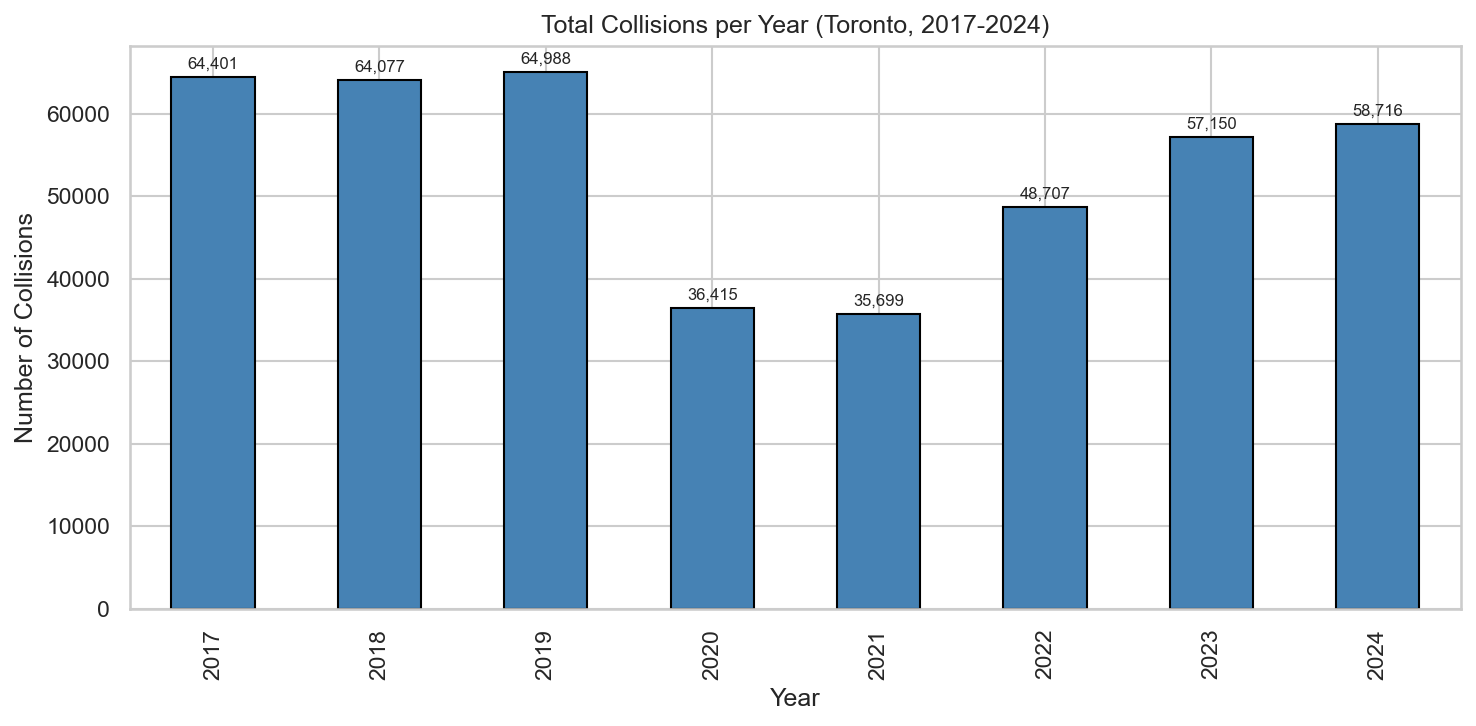

Saved: c:\Users\ADMIN\Desktop\TT\B2205935-LeNgocDuc-TranThanhPhuc-tuan-02\outputs\toronto_new/eda_yearly_trend.png


In [7]:
plt.figure(figsize=(10, 5))
yearly = t.groupby('Year').size()
ax = yearly.plot(kind='bar', color='steelblue', edgecolor='black')
for p in ax.containers[0]:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+1000),
                ha='center', fontsize=8, rotation=0)
plt.title('Total Collisions per Year (Toronto, 2017-2024)')
plt.ylabel('Number of Collisions'); plt.xlabel('Year')
plt.tight_layout()
plt.savefig(OM + '/eda_yearly_trend.png', dpi=150)
plt.show()
print(f'Saved: {OM}/eda_yearly_trend.png')

### 4.2 Collisions by Day of Week

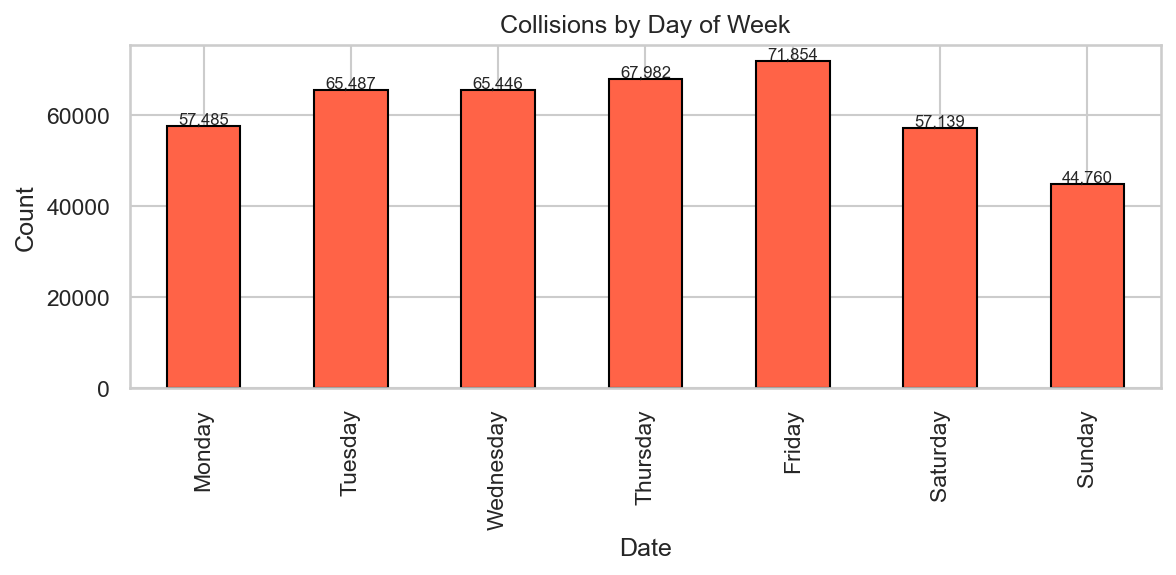

Weekend proportion: 23.7%


In [8]:
plt.figure(figsize=(8, 4))
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
t_dow = t['Date'].dt.day_name().value_counts().reindex(dow_order)
ax = t_dow.plot(kind='bar', color='tomato', edgecolor='black')
for p in ax.containers[0]:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+500), ha='center', fontsize=8)
plt.title('Collisions by Day of Week'); plt.ylabel('Count')
plt.tight_layout()
plt.savefig(OM + '/eda_dow.png', dpi=150)
plt.show()
weekend_pct = t_dow.loc[['Saturday','Sunday']].sum() / t_dow.sum() * 100
print(f'Weekend proportion: {weekend_pct:.1f}%')

### 4.3 Hourly Distribution

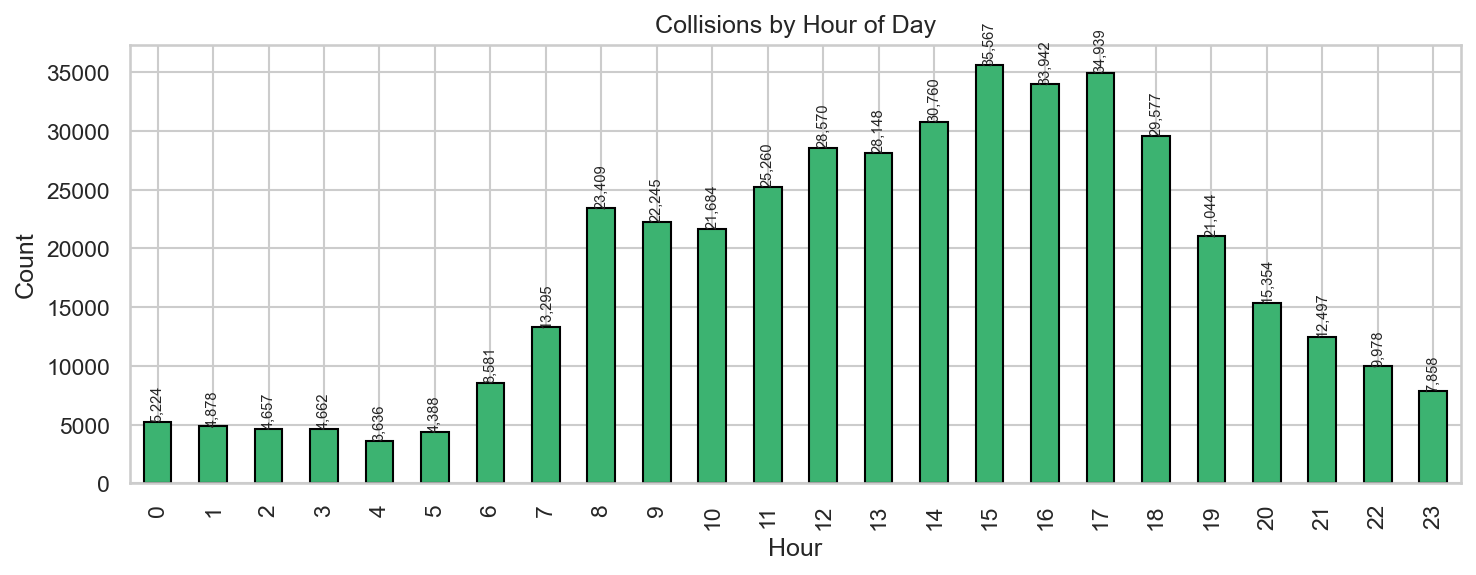

Peak hours: [15, 17, 16]


In [9]:
plt.figure(figsize=(10, 4))
hourly = t['Hour'].value_counts().sort_index()
ax = hourly.plot(kind='bar', color='mediumseagreen', edgecolor='black')
for p in ax.containers[0]:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+300),
                ha='center', fontsize=7, rotation=90)
plt.title('Collisions by Hour of Day'); plt.xlabel('Hour'); plt.ylabel('Count')
plt.tight_layout()
plt.savefig(OM + '/eda_hourly.png', dpi=150)
plt.show()
peak_hours = hourly.nlargest(3).index.tolist()
print(f'Peak hours: {peak_hours}')

### 4.4 Monthly Distribution

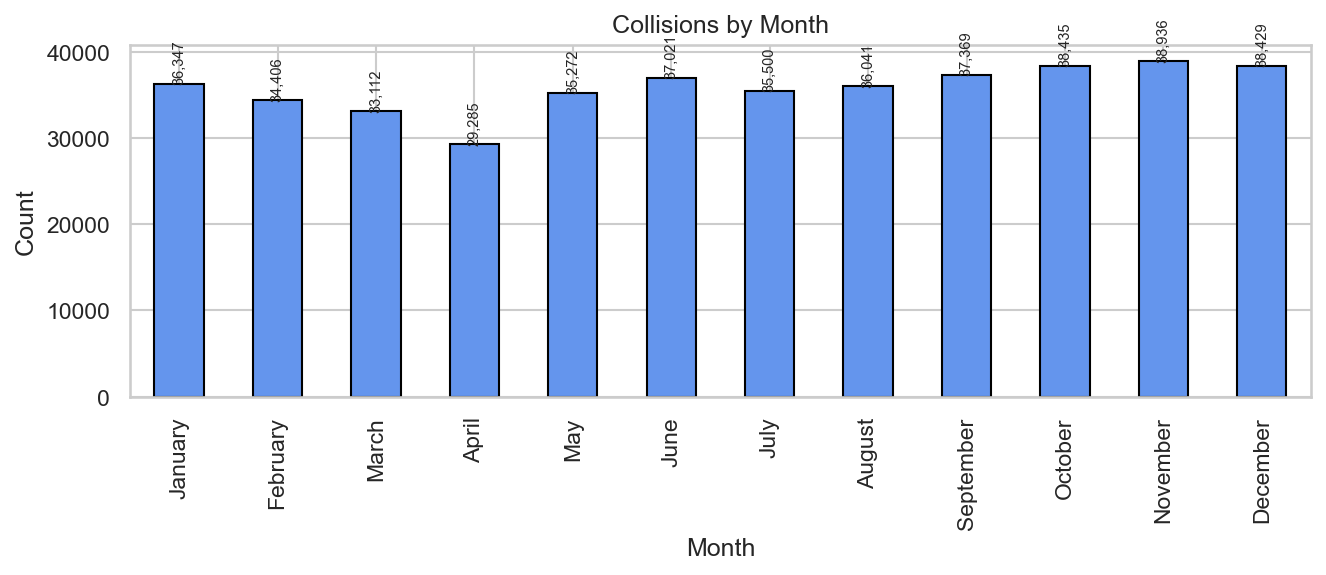

In [10]:
plt.figure(figsize=(9, 4))
monthly_t = t.groupby('Month').size().reindex([
    'January','February','March','April','May','June','July','August',
    'September','October','November','December'])
ax = monthly_t.plot(kind='bar', color='cornflowerblue', edgecolor='black')
for p in ax.containers[0]:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+300),
                ha='center', fontsize=7, rotation=90)
plt.title('Collisions by Month'); plt.xlabel('Month'); plt.ylabel('Count')
plt.tight_layout()
plt.savefig(OM + '/eda_monthly.png', dpi=150)
plt.show()

### 4.5 Top Neighbourhood Hotspots

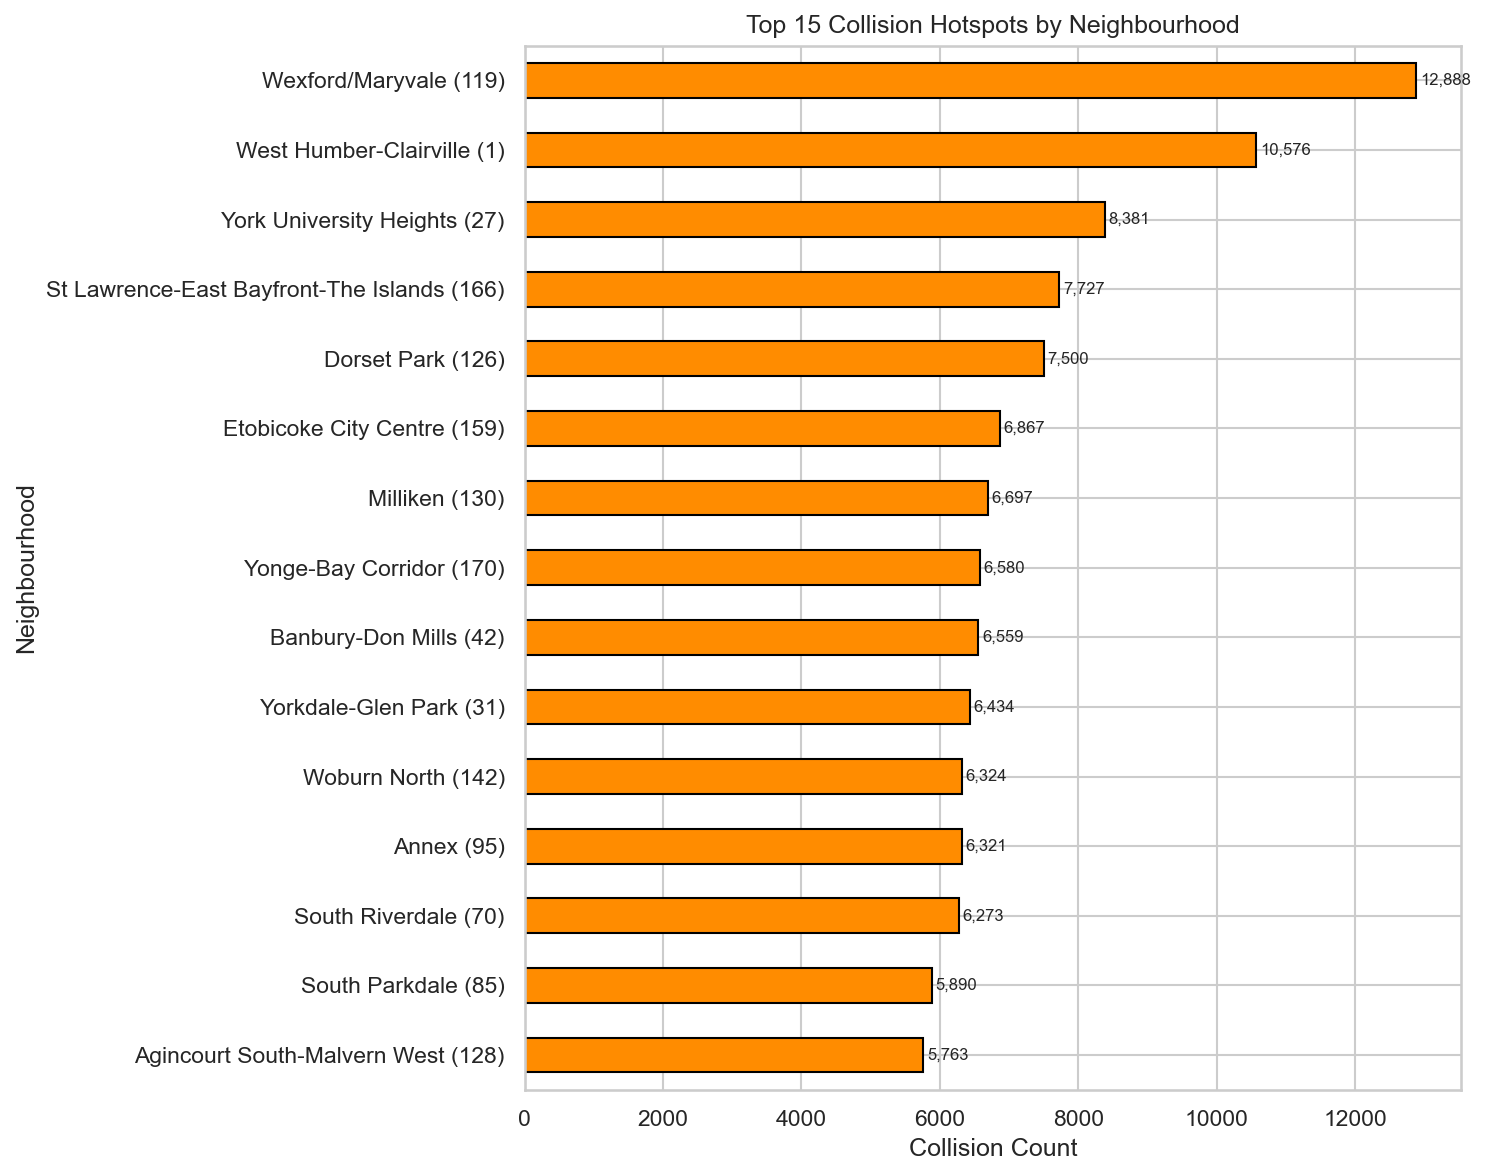

Top neighbourhood: Wexford/Maryvale (119) (12,888)


In [11]:
plt.figure(figsize=(10, 8))
nhood = t['Neighbourhood'].value_counts().head(15)
ax = nhood.plot(kind='barh', color='darkorange', edgecolor='black')
for p in ax.containers[0]:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width()+50, p.get_y()+p.get_height()/2), va='center', fontsize=8)
ax.invert_yaxis()
plt.title('Top 15 Collision Hotspots by Neighbourhood'); plt.xlabel('Collision Count')
plt.tight_layout()
plt.savefig(OM + '/eda_hotspots.png', dpi=150)
plt.show()
print(f'Top neighbourhood: {nhood.index[0]} ({nhood.iloc[0]:,})')

### 4.6 INJURY Severity Distribution

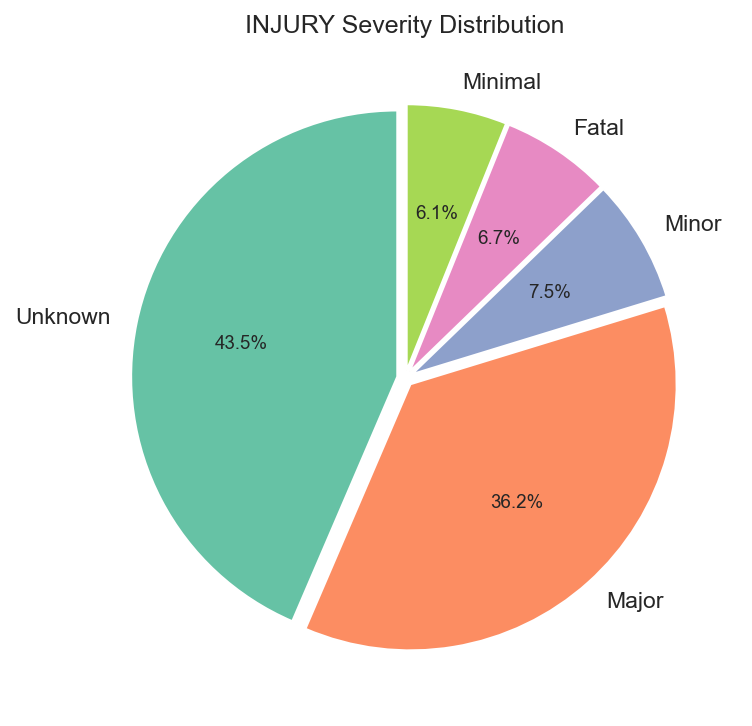

INJURY distribution: {'Unknown': 4145, 'Major': 3445, 'Minor': 714, 'Fatal': 635, 'Minimal': 580}


In [12]:
plt.figure(figsize=(7, 5))
inj_dist = k['INJURY'].value_counts()
colors = sns.color_palette('Set2', len(inj_dist))
wedges, texts, autotexts = plt.pie(inj_dist.values, labels=inj_dist.index, autopct='%1.1f%%',
                                    colors=colors, startangle=90, explode=[0.03]*len(inj_dist))
for at in autotexts: at.set_fontsize(9)
plt.title('INJURY Severity Distribution')
plt.tight_layout()
plt.savefig(OM + '/eda_injury_pie.png', dpi=150)
plt.show()
print(f'INJURY distribution: {inj_dist.to_dict()}')

### 4.7 ACCLASS Severity Breakdown

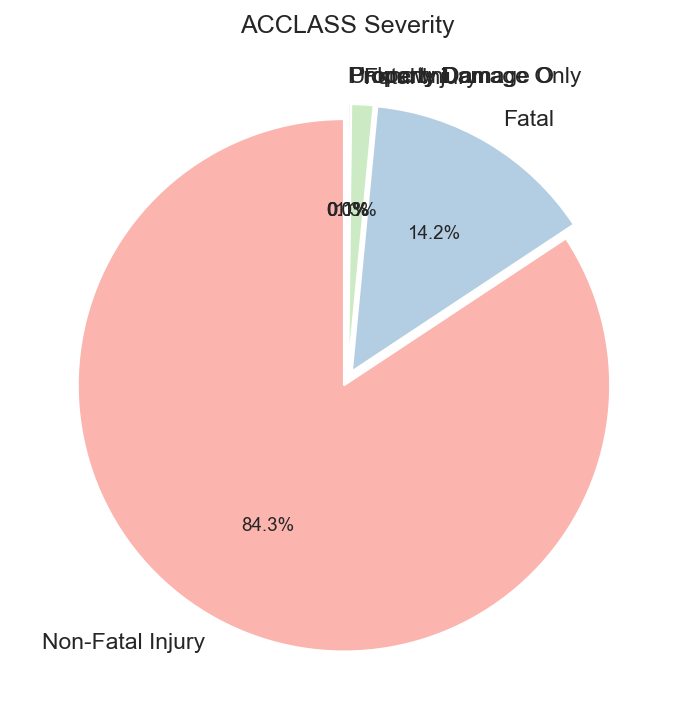

ACCLASS distribution: {'Non-Fatal Injury': 8025, 'Fatal': 1349, 'Fatal Injury': 128, 'Property Damage O': 14, 'Property Damage Only': 2, 'Unknown': 1}


In [13]:
plt.figure(figsize=(7, 5))
accl_dist = k['ACCLASS'].value_counts()
colors2 = sns.color_palette('Pastel1', len(accl_dist))
wedges2, texts2, autotexts2 = plt.pie(accl_dist.values, labels=accl_dist.index, autopct='%1.1f%%',
                                       colors=colors2, startangle=90, explode=[0.03]*len(accl_dist))
for at in autotexts2: at.set_fontsize(9)
plt.title('ACCLASS Severity')
plt.tight_layout()
plt.savefig(OM + '/eda_acclass_pie.png', dpi=150)
plt.show()
print(f'ACCLASS distribution: {accl_dist.to_dict()}')

### 4.8 Top Involved Person Types

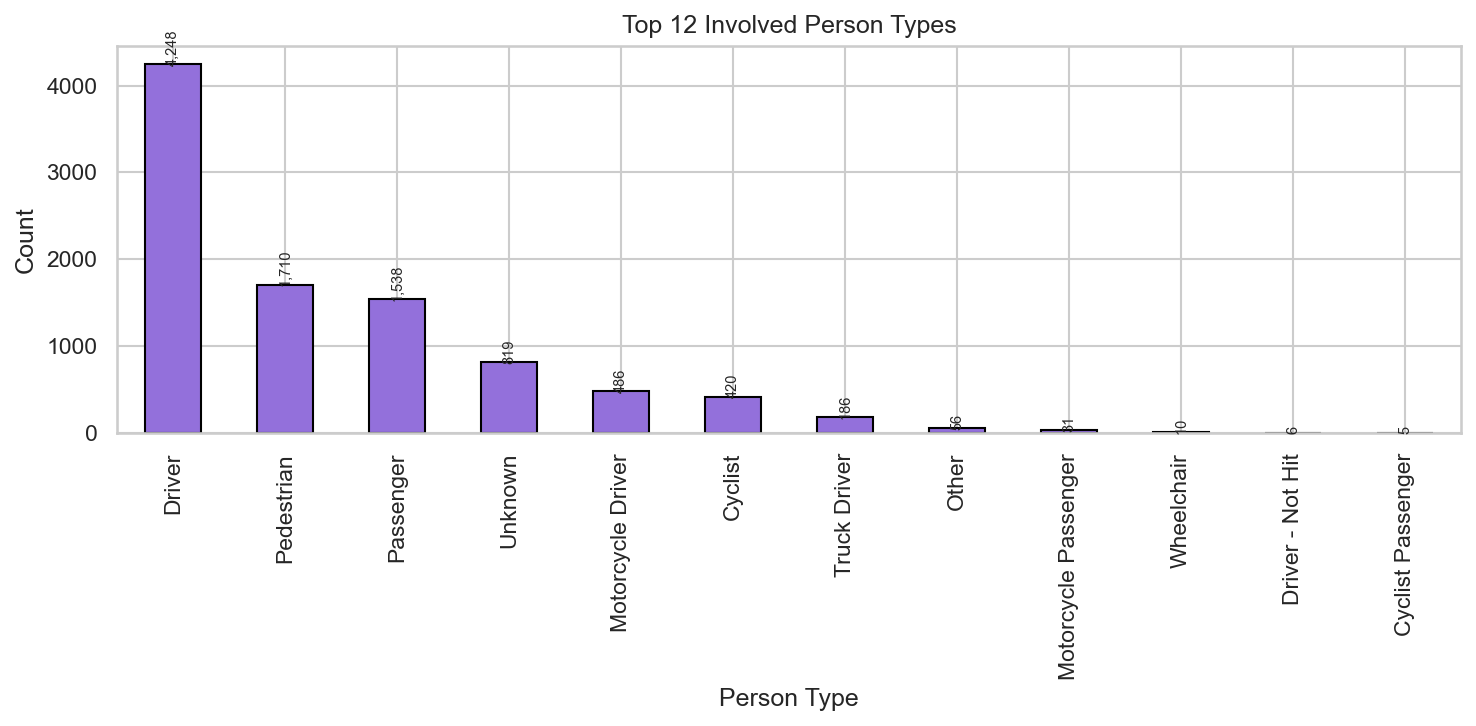

In [14]:
if 'INVTYPE' in k.columns:
    plt.figure(figsize=(10, 5))
    inv = k['INVTYPE'].value_counts().head(12)
    ax = inv.plot(kind='bar', color='mediumpurple', edgecolor='black')
    for p in ax.containers[0]:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+15),
                    ha='center', fontsize=7, rotation=90)
    plt.title('Top 12 Involved Person Types'); plt.xlabel('Person Type'); plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(OM + '/eda_invtype.png', dpi=150)
    plt.show()

### 4.9 Top Driver Actions & Speeding

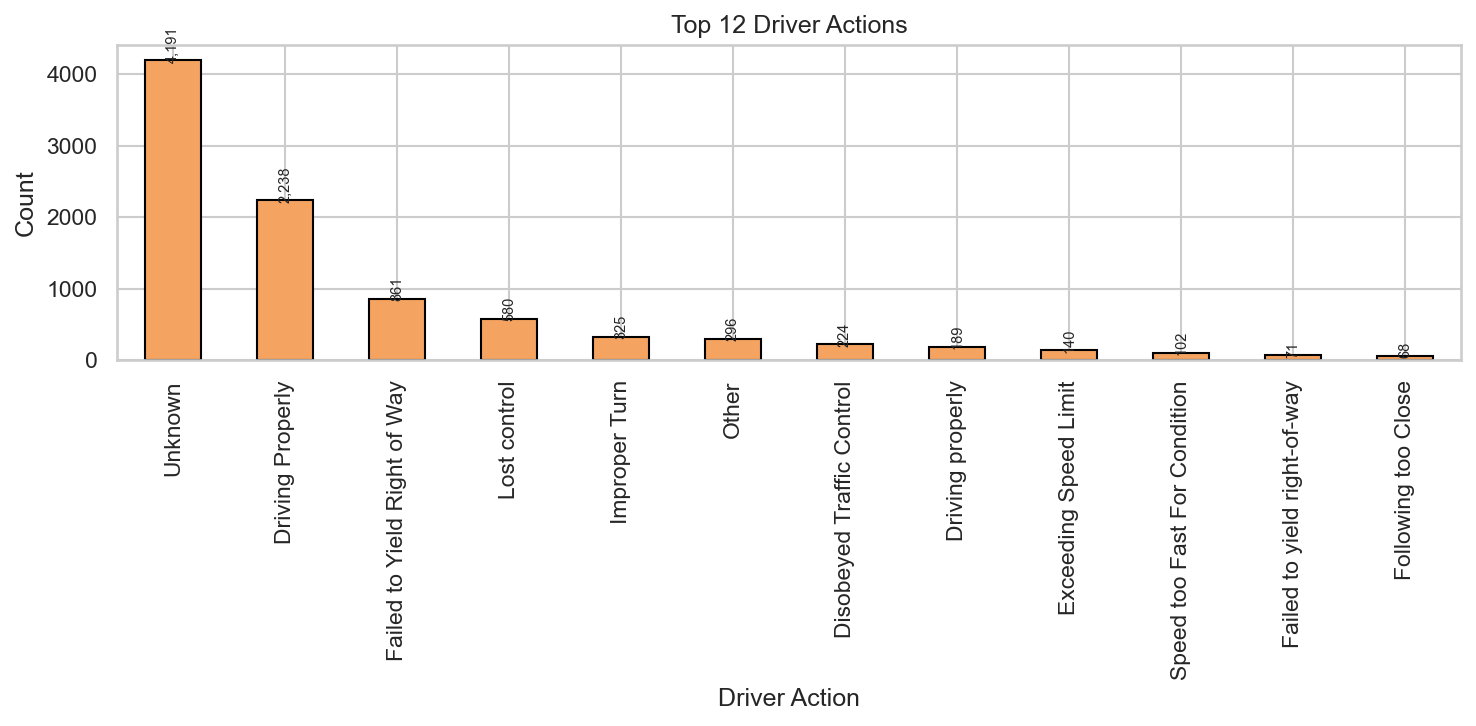

Speeding involvement: 63.6%


In [15]:
if 'DRIVACT' in k.columns:
    plt.figure(figsize=(10, 5))
    da = k['DRIVACT'].value_counts().head(12)
    ax = da.plot(kind='bar', color='sandybrown', edgecolor='black')
    for p in ax.containers[0]:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+10),
                    ha='center', fontsize=7, rotation=90)
    plt.title('Top 12 Driver Actions'); plt.xlabel('Driver Action'); plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(OM + '/eda_drivact.png', dpi=150)
    plt.show()

if 'SPEEDING' in k.columns:
    spd_pct = k['SPEEDING'].value_counts(normalize=True).get('Yes', 0) * 100
    print(f'Speeding involvement: {spd_pct:.1f}%')

### 4.10 Environmental Conditions

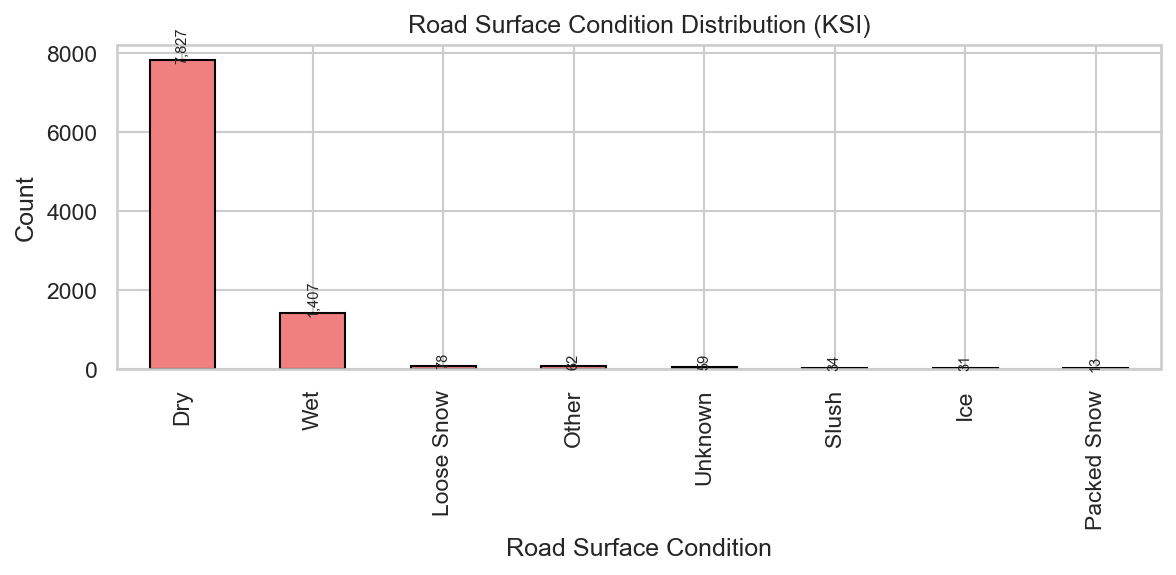

Top Road Surface Condition: Dry (7,827)


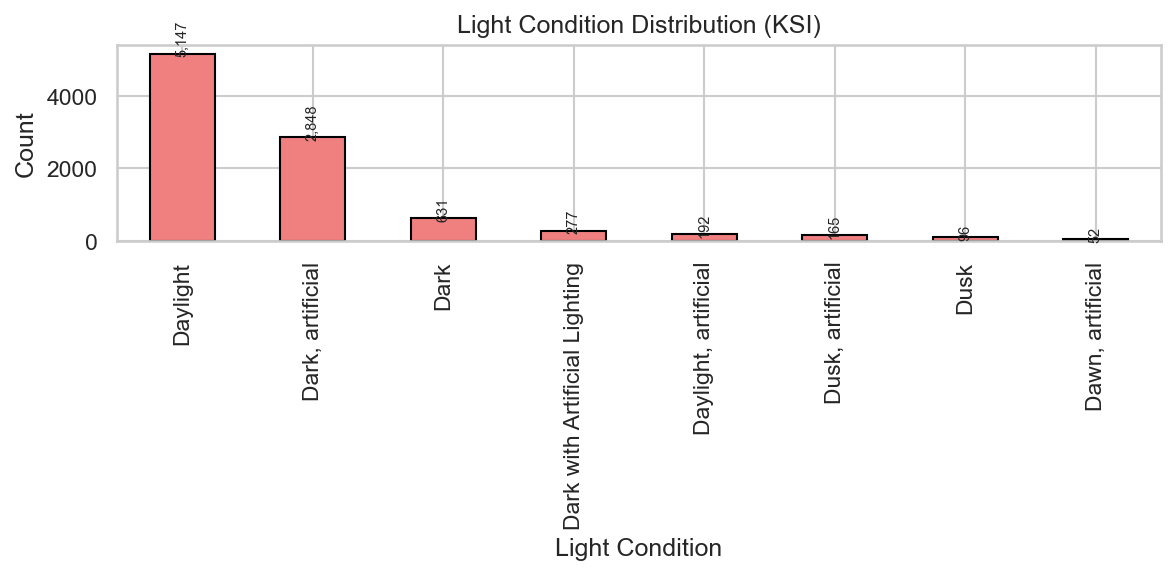

Top Light Condition: Daylight (5,147)


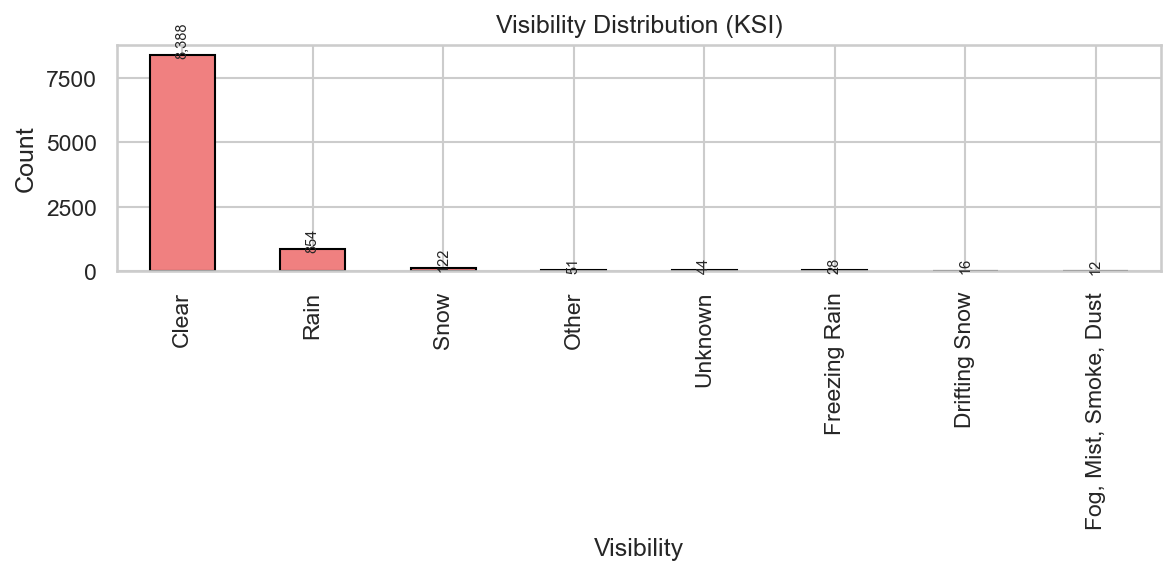

Top Visibility: Clear (8,388)


In [16]:
for feat, title, fn in [('RDSFCOND','Road Surface Condition','roadsfc'),
                          ('LIGHT','Light Condition','light'),
                          ('VISIBILITY','Visibility','vis')]:
    if feat not in k.columns: continue
    plt.figure(figsize=(8, 4))
    d = k[feat].value_counts().head(8)
    ax = d.plot(kind='bar', color='lightcoral', edgecolor='black')
    for p in ax.containers[0]:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+10),
                    ha='center', fontsize=7, rotation=90)
    plt.title(f'{title} Distribution (KSI)'); plt.xlabel(title); plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(OM + f'/eda_{fn}.png', dpi=150)
    plt.show()
    top = d.index[0]
    print(f'Top {title}: {top} ({d.iloc[0]:,})')

### 4.11 Impact Type Distribution

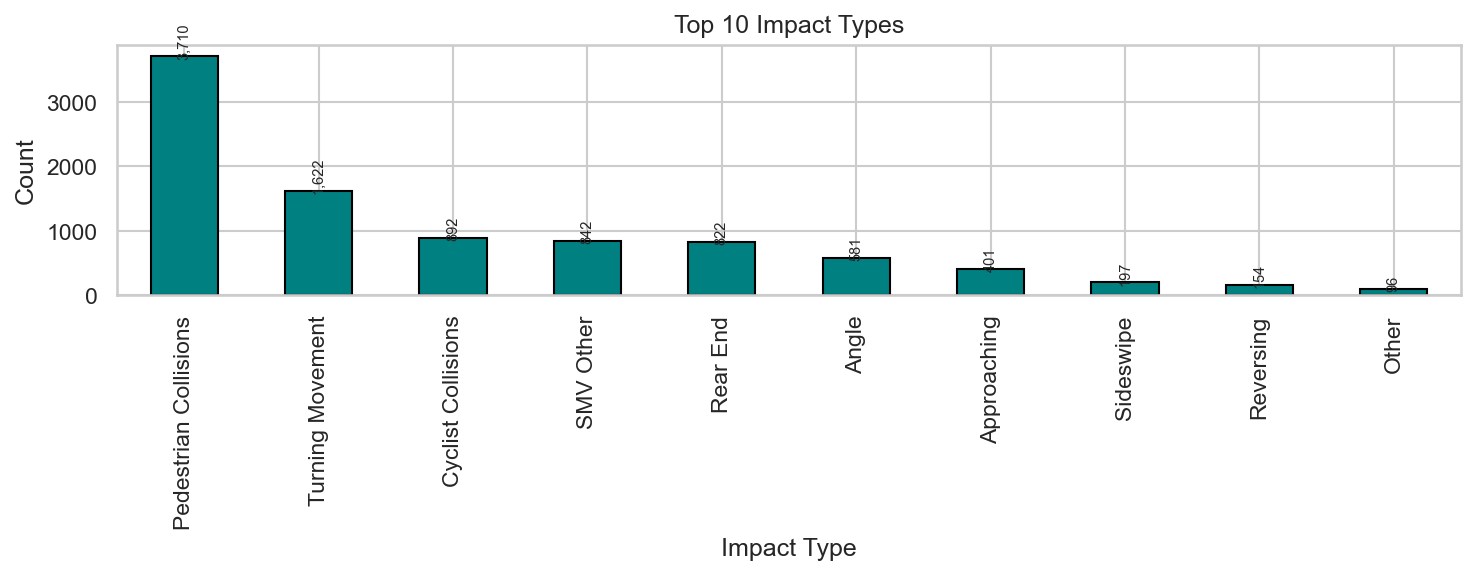

In [17]:
if 'IMPACTYPE' in k.columns:
    plt.figure(figsize=(10, 4))
    imp = k['IMPACTYPE'].value_counts().head(10)
    ax = imp.plot(kind='bar', color='teal', edgecolor='black')
    for p in ax.containers[0]:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+10),
                    ha='center', fontsize=7, rotation=90)
    plt.title('Top 10 Impact Types'); plt.xlabel('Impact Type'); plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(OM + '/eda_impactype.png', dpi=150)
    plt.show()

### 4.12 250m Grid Spatial Heatmap

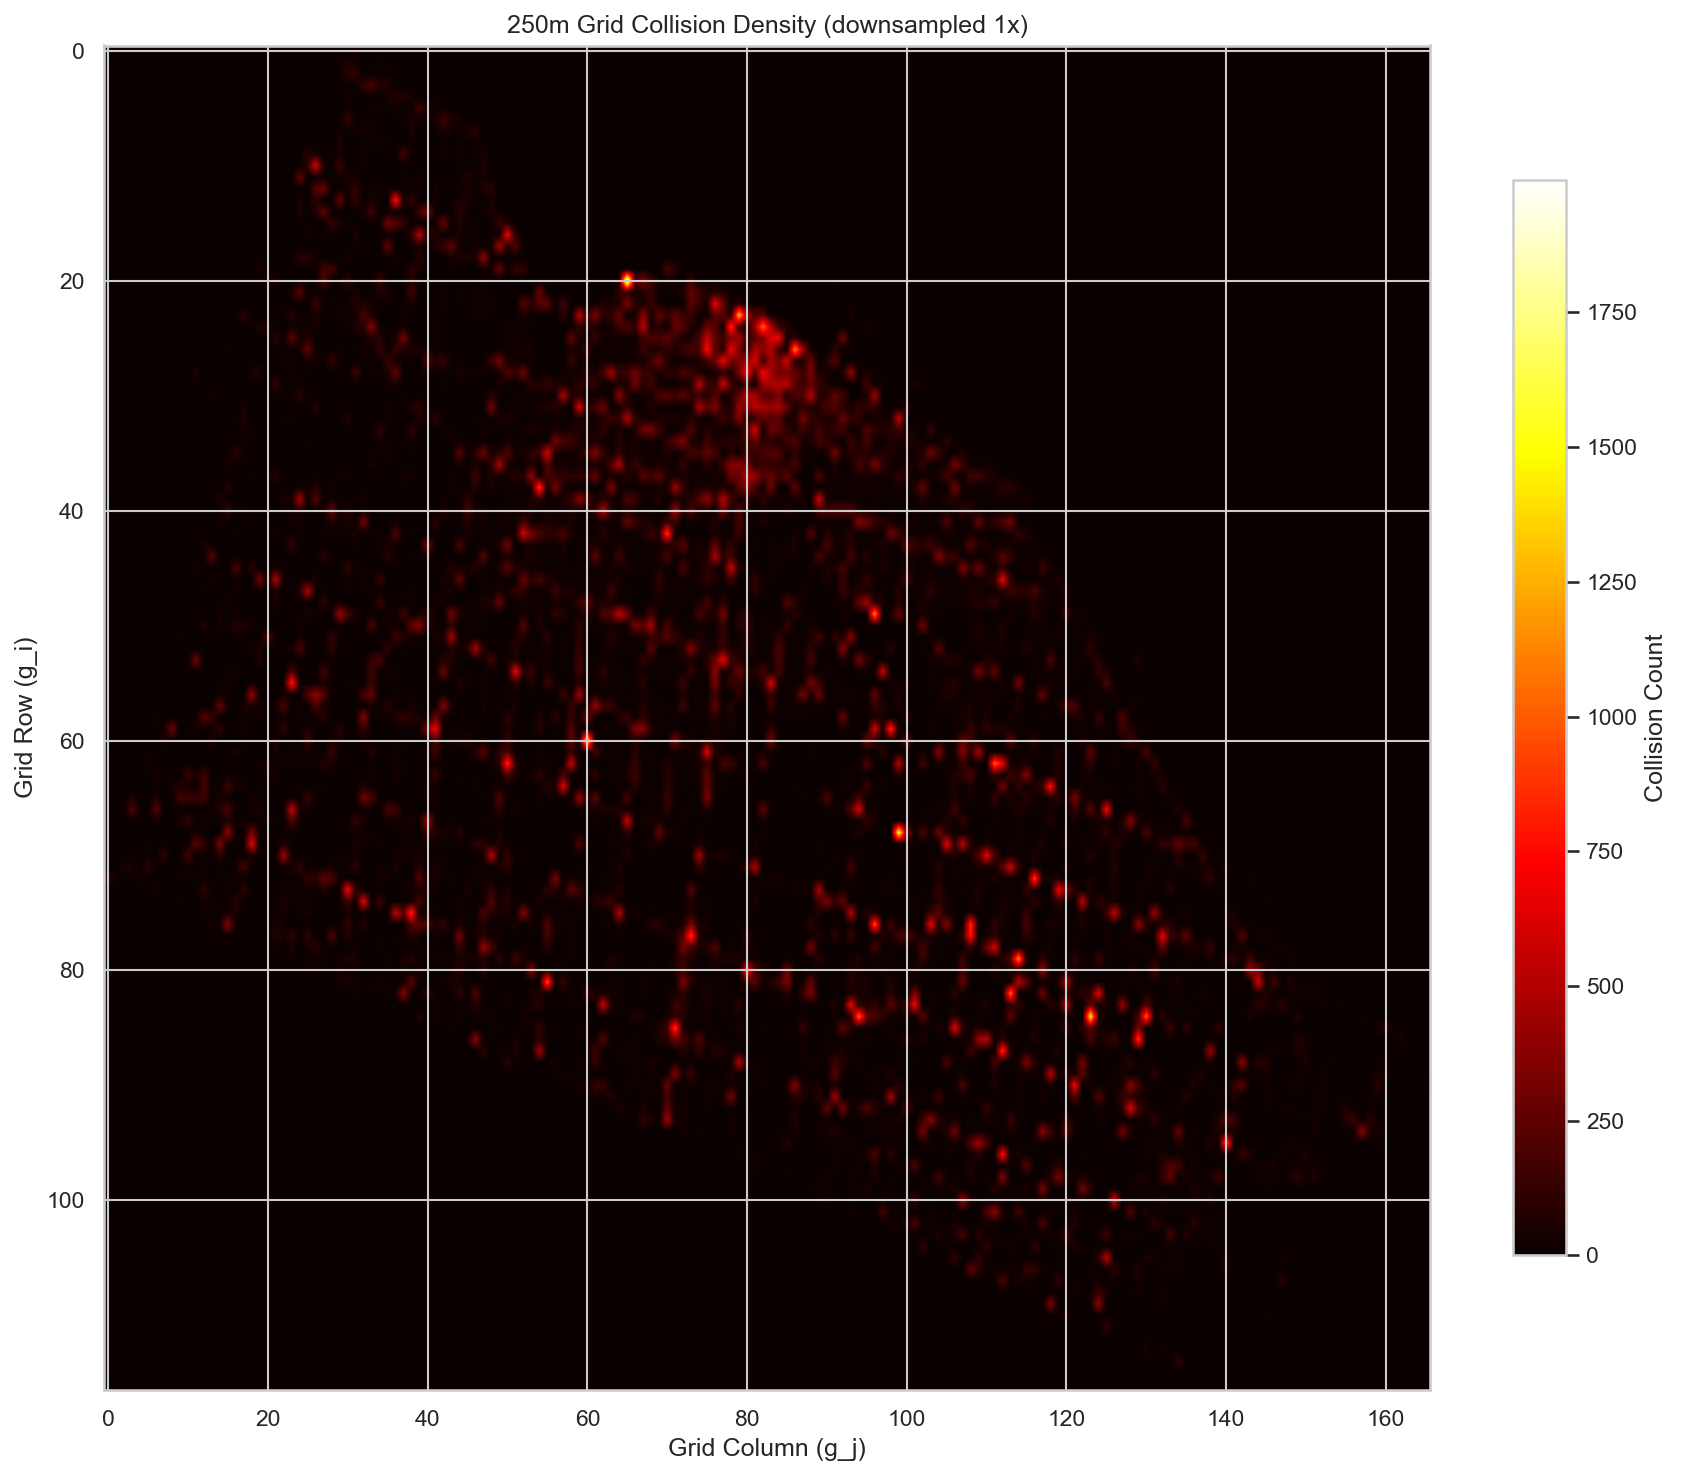

In [18]:
lat_c, lon_c = 0.00225, 0.003125
plt.figure(figsize=(12, 10))
tg = t[['Latitude', 'Longitude']].dropna().copy()
tg['Latitude'] = pd.to_numeric(tg['Latitude'], errors='coerce')
tg['Longitude'] = pd.to_numeric(tg['Longitude'], errors='coerce')
tg['g_i'] = ((tg['Latitude'] - tg['Latitude'].min()) / lat_c).astype(int)
tg['g_j'] = ((tg['Longitude'] - tg['Longitude'].min()) / lon_c).astype(int)
grid_counts = tg.groupby(['g_i', 'g_j']).size().reset_index(name='count')
pivot = grid_counts.pivot_table(index='g_i', columns='g_j', values='count', fill_value=0)
step = max(1, min(pivot.shape[0], pivot.shape[1]) // 80)
pivot_small = pivot.iloc[::step, ::step] if step > 1 else pivot
plt.imshow(pivot_small.values, cmap='hot', aspect='auto', interpolation='bilinear')
plt.colorbar(label='Collision Count', shrink=0.8)
plt.title(f'250m Grid Collision Density (downsampled {step}x)')
plt.xlabel('Grid Column (g_j)'); plt.ylabel('Grid Row (g_i)')
plt.tight_layout()
plt.savefig(OM + '/eda_grid_250m.png', dpi=150)
plt.show()

### 4.13 Hourly Grid Activity at Peak Hours (15:00-17:00)

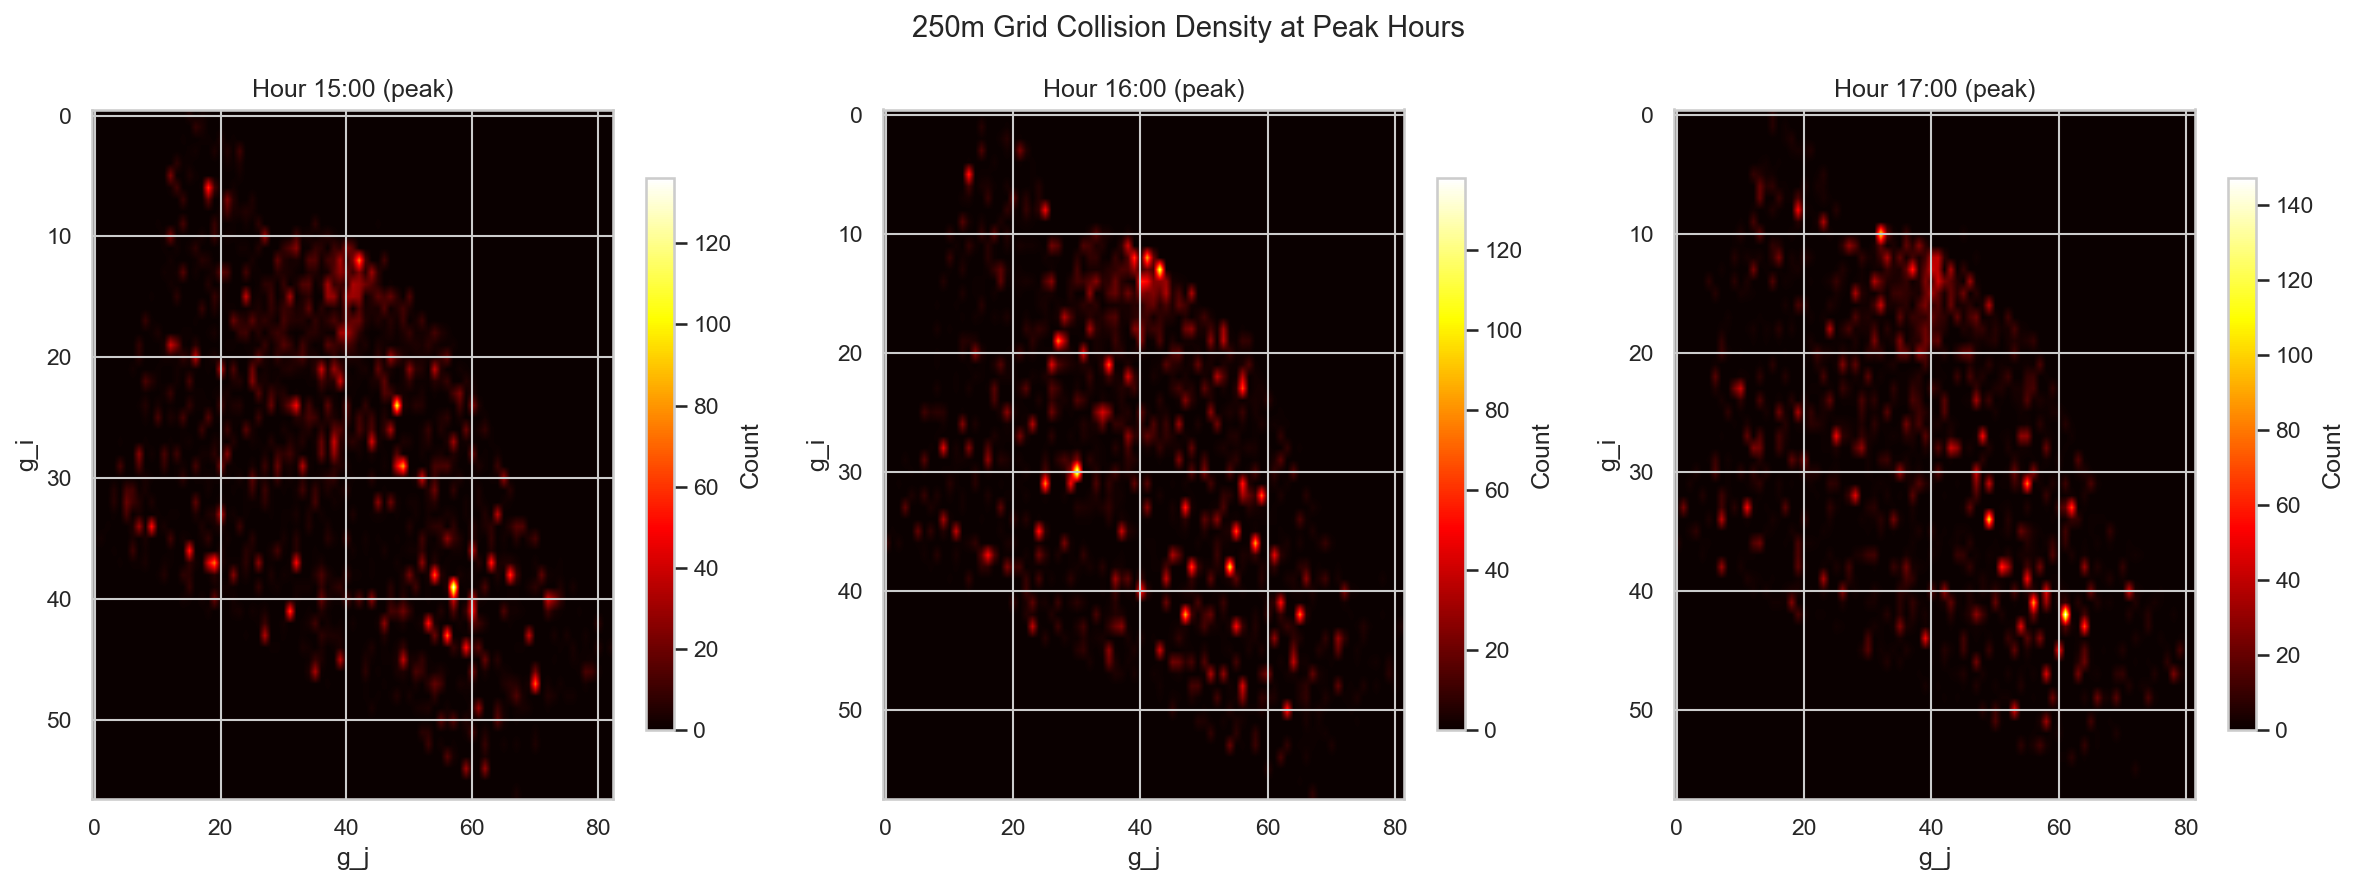

In [19]:
t_with_grid = t[['Latitude', 'Longitude', 'Hour']].copy()
t_with_grid['Hour'] = pd.to_numeric(t_with_grid['Hour'], errors='coerce')
t_with_grid = t_with_grid.dropna(subset=['Hour', 'Latitude', 'Longitude'])
t_with_grid['g_i'] = ((t_with_grid['Latitude'] - t_with_grid['Latitude'].min()) / lat_c).astype(int)
t_with_grid['g_j'] = ((t_with_grid['Longitude'] - t_with_grid['Longitude'].min()) / lon_c).astype(int)

plt.figure(figsize=(16, 6))
peak_hrs = [15, 16, 17]
for idx, hr in enumerate(peak_hrs):
    hr_data = t_with_grid[t_with_grid['Hour'] == hr]
    if len(hr_data) < 10: continue
    g_hr = hr_data.groupby(['g_i', 'g_j']).size().reset_index(name='count')
    piv_hr = g_hr.pivot_table(index='g_i', columns='g_j', values='count', fill_value=0)
    step_hr = max(1, min(piv_hr.shape[0], piv_hr.shape[1]) // 50)
    pv = piv_hr.iloc[::step_hr, ::step_hr] if step_hr > 1 else piv_hr
    plt.subplot(1, 3, idx+1)
    plt.imshow(pv.values, cmap='hot', aspect='auto', interpolation='bilinear')
    plt.colorbar(label='Count', shrink=0.8)
    plt.title(f'Hour {hr}:00 (peak)')
    plt.xlabel('g_j'); plt.ylabel('g_i')
plt.suptitle('250m Grid Collision Density at Peak Hours', fontsize=14)
plt.tight_layout()
plt.savefig(OM + '/eda_grid_hourly.png', dpi=150)
plt.show()

---
## 5. Binary Classification (Traffic: Injury_Collisions)
Predict whether a collision results in injury using XGBoost with scale_pos_weight for imbalance.

In [20]:
tb = t.copy()
tb['target'] = tb['Injury_Collisions'].map({'YES': 1, 'NO': 0}).fillna(0).astype(int)
tb['Year'] = pd.to_numeric(tb['Year'], errors='coerce').fillna(0).astype(int)
month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
tb['Month'] = tb['Month'].map(month_map).fillna(1).astype(int)
tb['Hour'] = pd.to_numeric(tb['Hour'], errors='coerce').fillna(12).astype(int)
# Vehicle/condition indicators per paper
for c in ['ALCOHOL', 'DISABILITY', 'SPEEDING', 'PASSENGER', 'BICYCLE', 'PEDESTRIAN']:
    if c in tb.columns: tb[c] = tb[c].map({'Yes': 1, 'No': 0, 'YES': 1, 'NO': 0}).fillna(0).astype(int)
# AUTO kept as 'Yes' label per paper (not binary)
tb['is_weekend'] = (tb['Date'].dt.dayofweek >= 5).astype(int)
# Time_of_Day: 4 categories per paper
tb['Time_of_Day'] = pd.cut(tb['Hour'], bins=[-1, 5, 11, 17, 23], labels=[0, 1, 2, 3]).astype(int)
# Season derived from month names per paper (no numeric mapping)
tb['Season'] = tb['Month'].map({1:'Winter',2:'Winter',12:'Winter',3:'Spring',4:'Spring',5:'Spring',
                                 6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}).fillna('Winter')
tb['Latitude'] = pd.to_numeric(tb['Latitude'], errors='coerce').fillna(43.7).round(4)
tb['Longitude'] = pd.to_numeric(tb['Longitude'], errors='coerce').fillna(-79.4).round(4)
tb['g_i'] = ((tb['Latitude'] - tb['Latitude'].min()) / lat_c).fillna(0).astype(int)
tb['g_j'] = ((tb['Longitude'] - tb['Longitude'].min()) / lon_c).fillna(0).astype(int)

tr = tb[tb['Date'] < '2023-01-01'].copy()
te = tb[tb['Date'] >= '2023-01-01'].copy()
print(f'Train: {len(tr):,}, Test: {len(te):,}')

drop_cols = ['EventUniqueId', 'Date', 'Neighbourhood', 'Injury_Collisions',
             'Ftr_Collisions', 'Pd_Collisions', 'Fatalities']
for c in drop_cols:
    if c in tr.columns: tr.drop(columns=[c], inplace=True)
    if c in te.columns: te.drop(columns=[c], inplace=True)
for c in tr.select_dtypes(include=['object']).columns:
    m = tr[c].mode()
    tr[c] = tr[c].fillna(m[0] if len(m) > 0 else 'Unknown')
    if c in te.columns: te[c] = te[c].fillna(m[0] if len(m) > 0 else 'Unknown')
for c in tr.select_dtypes(include=['int64', 'float64']).columns:
    tr[c] = tr[c].fillna(tr[c].median())
    if c in te.columns: te[c] = te[c].fillna(tr[c].median())

traffic_cat = ['Police_Division', 'Season', 'DayOfWeek']
for c in traffic_cat[:]:
    if c not in tr.columns: traffic_cat.remove(c)
all_vals = {}
for c in traffic_cat:
    all_vals[c] = pd.concat([tr[c].astype(str), te[c].astype(str)]).unique()
    le = LabelEncoder(); le.fit(all_vals[c])
    tr[c + '_e'] = le.transform(tr[c].astype(str))
    te[c + '_e'] = le.transform(te[c].astype(str))

f_cols = ([c + '_e' for c in traffic_cat] +
          ['Year', 'Month', 'Hour', 'is_weekend', 'Time_of_Day', 
           'g_i', 'g_j', 'Latitude', 'Longitude'] +
          [c for c in ['ALCOHOL', 'DISABILITY', 'SPEEDING', 'PASSENGER', 'BICYCLE', 'PEDESTRIAN'] if c in tr.columns])
f_cols = [c for c in f_cols if c in tr.columns]
print(f'Features ({len(f_cols)}): {f_cols}')

Xtr = tr[f_cols].fillna(0).values; ytr = tr['target'].values
Xte = te[f_cols].fillna(0).values; yte = te['target'].values
# No StandardScaler for XGBoost (per paper)
print(f'Train class dist: {np.bincount(ytr)}, Test: {np.bincount(yte)}')

Train: 314,287, Test: 115,866
Features (15): ['Police_Division_e', 'Season_e', 'Year', 'Month', 'Hour', 'is_weekend', 'Time_of_Day', 'DayOfWeek', 'g_i', 'g_j', 'Latitude', 'Longitude', 'PASSENGER', 'BICYCLE', 'PEDESTRIAN']
Train class dist: [272537  41750], Test: [99229 16637]


In [22]:
Xtr2, Xval, ytr_v, yval = train_test_split(Xtr, ytr, test_size=0.1, random_state=42)
sw = (ytr_v == 0).sum() / max((ytr_v == 1).sum(), 1)
print(f'XGB+SW (scale_pos_weight={sw:.2f})...')
xgb = XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=150,
                    scale_pos_weight=sw, random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(Xtr2, ytr_v); yp_x = xgb.predict(Xte); pb_x = xgb.predict_proba(Xte)
acc_x = accuracy_score(yte, yp_x); auc_x = roc_auc_score(yte, pb_x[:,1])
prec_x = precision_score(yte, yp_x); rec_x = recall_score(yte, yp_x); f1_x = f1_score(yte, yp_x)
print(f'Acc={acc_x:.4f} AUC={auc_x:.4f} Prec={prec_x:.4f} Rec={rec_x:.4f} F1={f1_x:.4f}')

best_th, best_f1 = 0.5, 0
for th in np.arange(0.1, 0.9, 0.05):
    ypv = (xgb.predict_proba(Xval)[:,1] >= th).astype(int)
    fv = f1_score(yval, ypv)
    if fv > best_f1: best_f1, best_th = fv, th
yp_opt = (pb_x[:,1] >= best_th).astype(int)
print(f'Best th={best_th:.2f}: Acc={accuracy_score(yte, yp_opt):.4f} F1={f1_score(yte, yp_opt):.4f}')

XGB+SW (scale_pos_weight=6.53)...


ValueError: could not convert string to float: 'Tuesday'

## 6. Collision-Level Merge (Spatial Join Only)
KDTree/BallTree spatial-temporal join: match each Traffic event to the nearest KSI record.
**Note:** Classification removed per paper guidelines to avoid spatial target leakage.
Section 5 (traffic-only) is the canonical paper replication.

In [ ]:
k_ref = ksi_combined.copy()
k_ref.replace('<Null>', np.nan, inplace=True)
k_ref['INJURY'] = k_ref['INJURY'].fillna('Unknown')
inj_map_local = {'Unknown':0, 'Minimal':1, 'Minor':2, 'Major':3, 'Fatal':4}
k_ref['target'] = k_ref['INJURY'].map(inj_map_local).astype(int)
k_ref['Hour'] = pd.to_datetime(k_ref['DATE'], errors='coerce').dt.hour.fillna(12).astype(int)
k_ref = k_ref.dropna(subset=['LATITUDE','LONGITUDE'])

ksi_pts = np.column_stack([
    pd.to_numeric(k_ref['LATITUDE'], errors='coerce').values * 100,
    pd.to_numeric(k_ref['LONGITUDE'], errors='coerce').values * 100,
    k_ref['Hour'].values * 2,
])
t_pts = np.column_stack([
    pd.to_numeric(t['Latitude'], errors='coerce').values * 100,
    pd.to_numeric(t['Longitude'], errors='coerce').values * 100,
    pd.to_numeric(t['Hour'], errors='coerce').fillna(12).values * 2,
])

print('Building KDTree (%d KSI -> %d Traffic)...' % (len(ksi_pts), len(t_pts)))
tree_k = KDTree(ksi_pts)
dists_k, idx_k = tree_k.query(t_pts, k=1)

from sklearn.neighbors import BallTree
tree_b = BallTree(ksi_pts, leaf_size=40)
dists_b, idx_b = tree_b.query(t_pts, k=1)
if np.median(dists_b) < np.median(dists_k):
    dists_k, idx_k = dists_b, idx_b
    print('-> Using BallTree')
else:
    print('-> Using KDTree')

Building KDTree (24696 KSI -> 430153 Traffic)...
-> Using KDTree


## 7. Multiclass INJURY Severity (KSI Per-Person)
5-class ordinal classification using XGBoost with temporal train/test split.

In [ ]:
feats_all = ['IMPACTYPE', 'VISIBILITY', 'LIGHT', 'RDSFCOND', 'Year', 'Hour',
             'INVTYPE', 'VEHTYPE', 'ACCLOC', 'TRAFFCTL', 'HOOD_ID', 'Month',
             'INVAGE_std', 'ROAD_CLASS', 'DRIVACT', 'AG_DRIV', 'MANOEUVER',
             'DayOfWeek', 'DOY',
             'cell_collisions', 'cell_injury', 'cell_fatal', 'cell_injury_ratio',
             'cell_fatal_ratio', 'DRIVCOND', 'REDLIGHT']
feats_all = [c for c in feats_all if c in k.columns]
is_num = {'Year', 'Hour', 'Month', 'INVAGE_std', 'DOY',
          'cell_collisions', 'cell_injury', 'cell_fatal', 'cell_injury_ratio', 'cell_fatal_ratio'}
y = k['INJURY_ordinal'].values

X = pd.DataFrame()
for c in feats_all:
    if c not in k.columns: continue
    if c in is_num: X[c] = pd.to_numeric(k[c], errors='coerce').fillna(0)
    else:
        le = LabelEncoder()
        le.fit(k.loc[mask, c].astype(str))
        # Map unseen test labels to -1 to avoid data leakage
        X[c] = k[c].astype(str).map(lambda v: le.transform([v])[0] if v in le.classes_ else -1)
X.index = k.index

print(f'Features ({len(feats_all)}): {feats_all}')
print(f'X shape: {X.shape[0]:,d} x {X.shape[1]}')

mask = k['Year'].astype(int) <= 2022
X_tr, X_te = X.loc[mask], X.loc[~mask]
y_tr, y_te = y[mask], y[~mask]
print(f'Train: {X_tr.shape[0]:,d} (2006-2022), Test: {X_te.shape[0]:,d} (2023-2024)')
print(f'Train INJURY dist: {np.bincount(y_tr.astype(int))}')

Features (26): ['IMPACTYPE', 'VISIBILITY', 'LIGHT', 'RDSFCOND', 'Year', 'Hour', 'INVTYPE', 'VEHTYPE', 'ACCLOC', 'TRAFFCTL', 'HOOD_ID', 'Month', 'INVAGE_std', 'ROAD_CLASS', 'DRIVACT', 'AG_DRIV', 'MANOEUVER', 'DayOfWeek', 'DOY', 'cell_collisions', 'cell_injury', 'cell_fatal', 'cell_injury_ratio', 'cell_fatal_ratio', 'DRIVCOND', 'REDLIGHT']
X shape: 9,519 x 26
Train: 8,025 (2006-2022), Test: 1,494 (2023-2024)
Train INJURY dist: [3479  511  616 2878  541]


In [ ]:
# Per paper: same lr/n_est as binary, no subsample/colsample
params = {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.1,
          'random_state': 42}
model = XGBClassifier(**params, eval_metric='mlogloss', verbosity=0)
model.fit(X_tr, y_tr)
yp = model.predict(X_te)
mc_acc = accuracy_score(y_te, yp)

pb = model.predict_proba(X_te)
yb = label_binarize(y_te, classes=range(5))
pb = pb[:, :5]
class_aucs = []
for i in range(5):
    try: class_aucs.append(roc_auc_score(yb[:, i], pb[:, i]))
    except: class_aucs.append(0)

cl_names = ['Fatal','Major','Minimal','Minor','Unknown']
paper_auc = [0.96, 0.88, 0.96, 0.95, 0.87]
print('Temporal split results:')
for i, cl in enumerate(cl_names):
    gap = paper_auc[i] - class_aucs[i]
    print(f'  {cl:10s}  AUROC={class_aucs[i]:.4f} (paper: {paper_auc[i]:.2f}, gap={gap:.4f})')
print(f'  Accuracy: {mc_acc:.4f} (paper: ~0.83)')

Temporal split results:
  Fatal       AUROC=0.8754 (paper: 0.96, gap=0.0846)
  Major       AUROC=0.6686 (paper: 0.88, gap=0.2114)
  Minimal     AUROC=0.6523 (paper: 0.96, gap=0.3077)
  Minor       AUROC=0.8437 (paper: 0.95, gap=0.1063)
  Unknown     AUROC=0.8574 (paper: 0.87, gap=0.0126)
  Accuracy: 0.6867 (paper: ~0.83)


In [ ]:
# Ordered Logistic Regression baseline (multiclass LogisticRegression)
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_tr, y_tr)
yp_lr = lr.predict(X_te)
lr_acc = accuracy_score(y_te, yp_lr)

pb_lr = lr.predict_proba(X_te)
yb_lr = label_binarize(y_te, classes=range(5))
pb_lr = pb_lr[:, :5]
lr_aucs = []
for i in range(5):
    try: lr_aucs.append(roc_auc_score(yb_lr[:, i], pb_lr[:, i]))
    except: lr_aucs.append(0)

cl_names = ['Fatal','Major','Minimal','Minor','Unknown']
print('Logistic Regression baseline results:')
print(f'  Accuracy: {lr_acc:.4f} (XGBoost: {mc_acc:.4f})')
for i, cl in enumerate(cl_names):
    print(f'  {cl:10s}  AUROC={lr_aucs[i]:.4f} (XGBoost: {class_aucs[i]:.4f})')

Logistic Regression baseline results:
  Accuracy: 0.5415 (XGBoost: 0.6867)
  Fatal       AUROC=0.7124 (XGBoost: 0.8754)
  Major       AUROC=0.4864 (XGBoost: 0.6686)
  Minimal     AUROC=0.5027 (XGBoost: 0.6523)
  Minor       AUROC=0.6918 (XGBoost: 0.8437)
  Unknown     AUROC=0.7426 (XGBoost: 0.8574)


## 8. Grid Aggregation (250m cells x hour)
Aggregate collisions by grid cell, hour, and day-of-week. Train binary XGBoost and risk scoring.

In [ ]:
CELL_LAT, CELL_LON = 0.00225, 0.003125
ga = t[['Latitude', 'Longitude', 'Hour', 'Year', 'Date', 'Month',
        'Police_Division', 'Injury_Collisions', 'Ftr_Collisions', 'Pd_Collisions', 'Fatalities']].copy()
ga['Latitude'] = pd.to_numeric(ga['Latitude'], errors='coerce').fillna(43.7).round(4)
ga['Longitude'] = pd.to_numeric(ga['Longitude'], errors='coerce').fillna(-79.4).round(4)
ga['g_i'] = ((ga['Latitude'] - ga['Latitude'].min()) / CELL_LAT).fillna(0).astype(int)
ga['g_j'] = ((ga['Longitude'] - ga['Longitude'].min()) / CELL_LON).fillna(0).astype(int)
ga['Hour'] = pd.to_numeric(ga['Hour'], errors='coerce').fillna(12).astype(int)
ga['is_injury'] = ga['Injury_Collisions'].map({'YES':1,'NO':0}).fillna(0).astype(int)
ga['is_fatal'] = ga['Fatalities'].fillna(0).astype(int)
for col_ in ['Ftr_Collisions','Pd_Collisions']:
    if col_ in ga.columns:
        ga[col_] = pd.to_numeric(ga[col_], errors='coerce').fillna(0)
        if ga[col_].dtype == object:
            ga[col_] = ga[col_].map({'YES':1,'NO':0}).fillna(0).astype(int)
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
ga['Month'] = ga['Month'].map(month_map).fillna(1).astype(int)
ga['DayOfWeek'] = ga['Date'].dt.dayofweek.astype(int)

ga_tr = ga[ga['Year'].between(2017, 2022)].copy()
ga_te = ga[ga['Year'].between(2023, 2024)].copy()

grp_tr = ga_tr.groupby(['g_i','g_j','Hour','DayOfWeek'], as_index=False).agg(
    n_collisions=('is_injury','count'), n_injury=('is_injury','sum'),
    n_fatal=('is_fatal','sum'), n_ftr=('Ftr_Collisions','sum'),
    n_pd=('Pd_Collisions','sum'), avg_month=('Month','mean'),
).copy()
grp_te = ga_te.groupby(['g_i','g_j','Hour','DayOfWeek'], as_index=False).agg(
    n_collisions=('is_injury','count'), n_injury=('is_injury','sum'),
    n_fatal=('is_fatal','sum'), n_ftr=('Ftr_Collisions','sum'),
    n_pd=('Pd_Collisions','sum'), avg_month=('Month','mean'),
).copy()
grp_tr['target_binary'] = (grp_tr['n_injury'] > 0).astype(int)
grp_te['target_binary'] = (grp_te['n_injury'] > 0).astype(int)
print(f'Train grid cells: {len(grp_tr):,d}, Test grid cells: {len(grp_te):,d}')
print(f'Train binary dist: {grp_tr["target_binary"].value_counts().to_dict()}')

Train grid cells: 179,707, Test grid cells: 87,347
Train binary dist: {0: 142517, 1: 37190}


In [ ]:
# Per paper: spatial + temporal features only
bin_feats = ['g_i','g_j','Hour','DayOfWeek']
for c in ['SPEEDING', 'AG_DRIV']:
    if c in grp_tr.columns: bin_feats.append(c)
X_tr = grp_tr[bin_feats].fillna(0).values; y_tr = grp_tr['target_binary'].values
X_te = grp_te[bin_feats].fillna(0).values; y_te = grp_te['target_binary'].values
sw = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
print(f'Train: {len(X_tr):,d}, Test: {len(X_te):,d}, SW={sw:.2f}')
xgb_bin_g = XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=150,
                          scale_pos_weight=sw, random_state=42, eval_metric='logloss')
xgb_bin_g.fit(X_tr, y_tr)
yp_bin = xgb_bin_g.predict(X_te); pb_bin = xgb_bin_g.predict_proba(X_te)[:,1]
print(f'Acc={accuracy_score(y_te, yp_bin):.4f} AUC={roc_auc_score(y_te, pb_bin):.4f} '
      f'Prec={precision_score(y_te, yp_bin):.4f} Rec={recall_score(y_te, yp_bin):.4f} F1={f1_score(y_te, yp_bin):.4f}')

Train: 179,707, Test: 87,347, SW=3.83
Acc=0.7332 AUC=0.6222 Prec=0.2988 Rec=0.3521 F1=0.3233


## 9. Spatio-Temporal Grid RF
Random Forest Regressor predicting collision count per (grid, hour, day-of-week).

In [ ]:
gg = t[['Latitude', 'Longitude', 'Hour', 'Year', 'Date']].copy()
gg['DayOfWeek'] = gg['Date'].dt.day_name()
gg['Latitude'] = pd.to_numeric(gg['Latitude'], errors='coerce').fillna(43.7).round(4)
gg['Longitude'] = pd.to_numeric(gg['Longitude'], errors='coerce').fillna(-79.4).round(4)
gg['g_i'] = ((gg['Latitude'] - gg['Latitude'].min()) / CELL_LAT).fillna(0).astype(int)
gg['g_j'] = ((gg['Longitude'] - gg['Longitude'].min()) / CELL_LON).fillna(0).astype(int)
gg['DayOfWeek_e'] = LabelEncoder().fit_transform(gg['DayOfWeek'].astype(str))
gf = ['g_i', 'g_j', 'Hour', 'DayOfWeek_e', 'Year']
ga2 = gg.groupby(gf).size().reset_index(name='count')
tr_g = ga2[ga2['Year'].between(2017, 2022)]
te_g = ga2[ga2['Year'].between(2023, 2024)]
print(f'Train: {len(tr_g):,}, Test: {len(te_g):,}')
if len(tr_g) > 0 and len(te_g) > 0:
    gf_no_year = ['g_i', 'g_j', 'Hour', 'DayOfWeek_e']
    rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_reg.fit(tr_g[gf_no_year].fillna(0), tr_g['count'])
    preds = rf_reg.predict(te_g[gf_no_year].fillna(0))
    rmse = np.sqrt(mean_squared_error(te_g['count'], preds))
    print(f'RMSE: {rmse:.2f} (paper: 1.77)')
else:
    rmse = None

Train: 266,601, Test: 98,014
RMSE: 0.52 (paper: 1.77)


## 10. ARIMA Time Series
Walk-forward validation of monthly collision counts.

In [ ]:
ts = traffic.copy()
ts['OCC_DATE'] = pd.to_datetime(ts['OCC_DATE'], errors='coerce')
monthly = ts.set_index('OCC_DATE').resample('ME').size()
train_m = monthly[monthly.index < '2023-01-01']
test_m = monthly[monthly.index >= '2023-01-01']
print(f'Train months: {len(train_m)}, Test months: {len(test_m)}')

history = train_m.tolist()
predictions_arima = []
for t_idx in range(len(test_m)):
    model = SARIMAX(history, order=(1,1,1), seasonal_order=(1,1,1,12),
                    enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False, maxiter=50)
    fc = fit.forecast(1)[0]
    predictions_arima.append(fc)
    history.append(test_m.iloc[t_idx])
predictions_arima = np.array(predictions_arima)
rmse_arima = np.sqrt(mean_squared_error(test_m, predictions_arima))
print(f'ARIMA Walk-Forward RMSE: {rmse_arima:.0f}')

Train months: 72, Test months: 24


c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

ARIMA Walk-Forward RMSE: 391


In [ ]:
# Prophet model for monthly collision forecasting
try:
    from prophet import Prophet
    pdf = monthly.reset_index()
    pdf.columns = ['ds', 'y']
    train_p = pdf[pdf['ds'] < '2023-01-01'].copy()
    test_p = pdf[pdf['ds'] >= '2023-01-01'].copy()

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(train_p)
    future = m.make_future_dataframe(periods=len(test_p), freq='ME')
    forecast = m.predict(future)
    preds_p = forecast.tail(len(test_p))['yhat'].values
    rmse_p = np.sqrt(mean_squared_error(test_p['y'], preds_p))
    print(f'Prophet Walk-Forward RMSE: {rmse_p:.0f} (ARIMA: {rmse_arima:.0f})')
except ImportError:
    print('Prophet not installed. Skipping. Install with: pip install prophet')

Importing plotly failed. Interactive plots will not work.
19:33:09 - cmdstanpy - INFO - Chain [1] start processing
19:33:09 - cmdstanpy - INFO - Chain [1] done processing


Prophet Walk-Forward RMSE: 2566 (ARIMA: 391)


## 11. CA Simulation (Nagel-Schreckenberg)
Cellular automata traffic flow simulation with lane-changing.

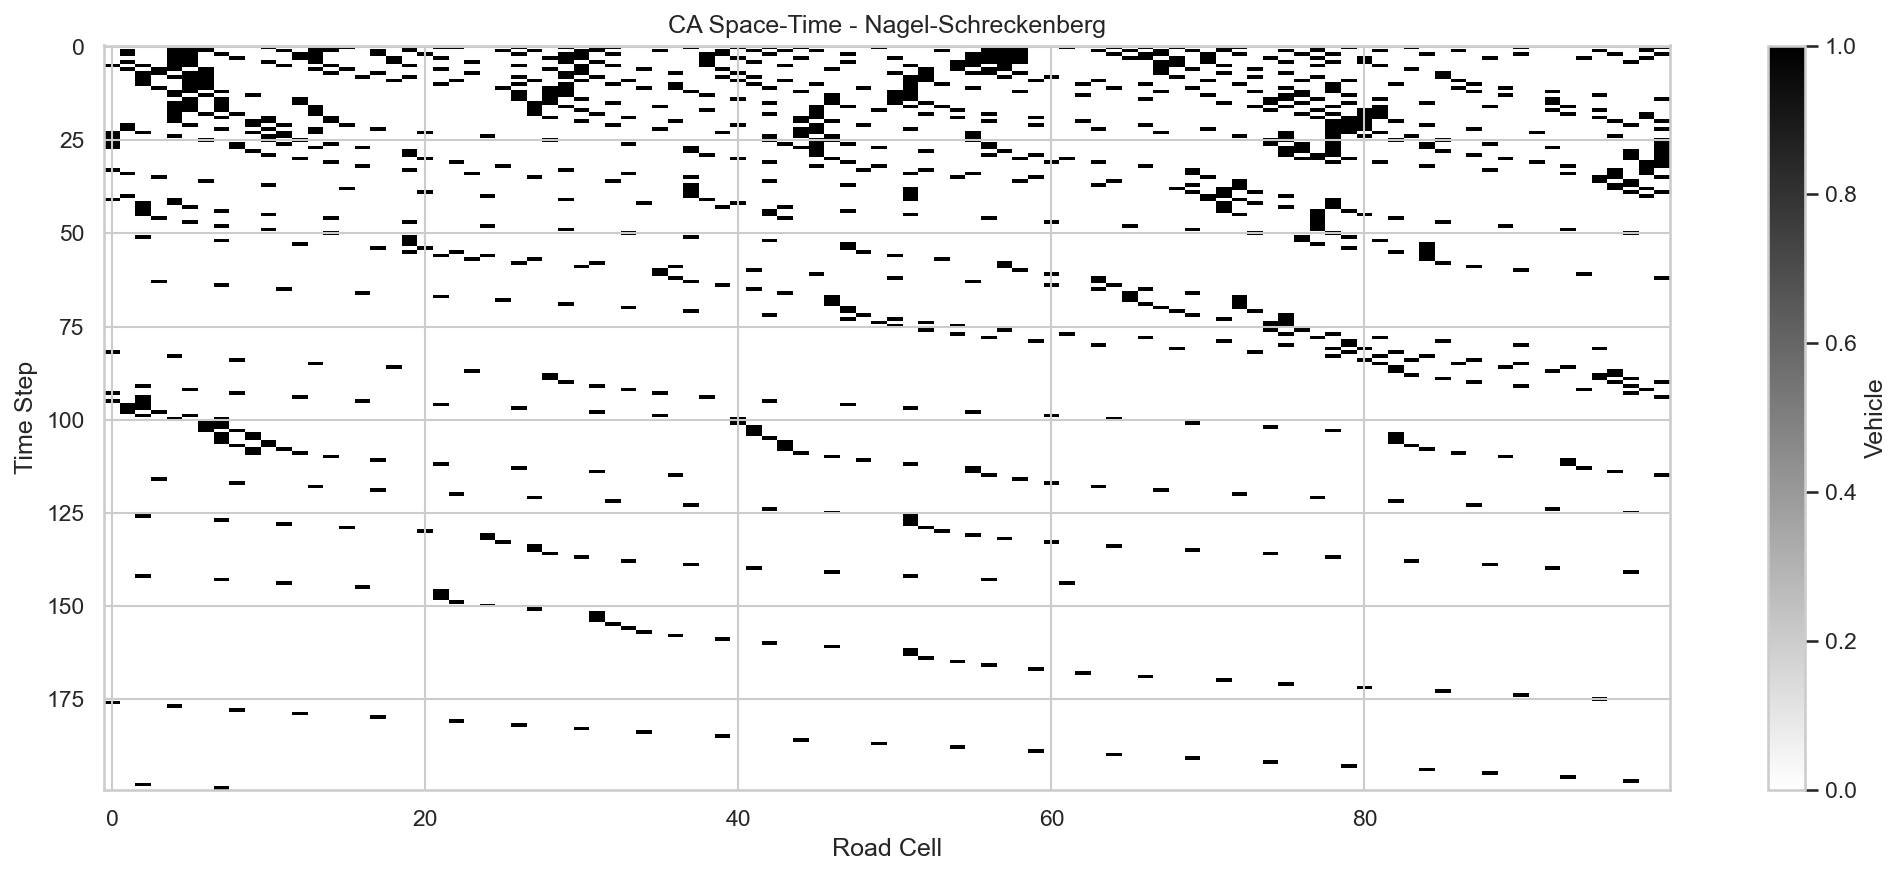

In [ ]:
P_SLOW, P_STOP, LCP = 0.3, 0.1, 0.2
V_MAX, L, LN, DENS, TS = 5, 100, 2, 0.3, 20  # TS=20 per paper

def ns_step(r, v, ps):
    Li, nv = len(r), v.copy(); nr = r.copy()
    for i in range(Li):
        if r[i] == 0: continue
        nv[i] = min(nv[i] + 1, V_MAX); d = 1
        while d < Li and r[(i + d) % Li] == 0: d += 1
        nv[i] = min(nv[i], d - 1)
        if np.random.random() < ps and nv[i] > 0: nv[i] -= 1  # ps handles both slowdown and stop
        p = (i + nv[i]) % Li; nr[i] = 0; nr[p] = 1
        if p != i: nv[p] = nv[i]; nv[i] = 0
    return nr.astype(int), nv.astype(int)

def lc(r, v):
    Li, LLP = r.shape[1], LCP
    for i in range(Li):
        for ln in range(r.shape[0] - 1):
            ot = ln + 1
            if r[ln, i] == 1 and r[ot, i] == 0:
                if all(r[ot, (i+d)%Li] == 0 for d in range(1, v[ln, i]+1)):
                    if np.random.random() < LLP:
                        r[ot, i] = 1; r[ln, i] = 0; v[ot, i] = v[ln, i]; v[ln, i] = 0
    return r, v

np.random.seed(42)
r = (np.random.random((LN, L)) < DENS).astype(int)
v = np.random.randint(1, V_MAX+1, (LN, L)).astype(int) * r
st = np.zeros((TS, L))
for ti in range(TS):
    st[ti] = r[0].copy()
    for ln in range(LN): r[ln], v[ln] = ns_step(r[ln], v[ln], P_SLOW)
    r, v = lc(r, v)

plt.figure(figsize=(14, 6))
plt.imshow(st, aspect='auto', cmap='binary', interpolation='nearest')
plt.xlabel('Road Cell'); plt.ylabel('Time Step')
plt.title('CA Space-Time - Nagel-Schreckenberg')
plt.colorbar(label='Vehicle')
plt.tight_layout()
plt.savefig(OM + '/ca_new.png', dpi=150)
plt.show()

## 12. CPA — Congestion Pattern Accuracy
Compare spatial autocorrelation (Moran's I) between real collision grid and CA density.

In [ ]:
# CPA per paper: matched congested cells ratio (not Moran's I)
g_hot = tb[['g_i', 'g_j']].dropna().astype(int)
real_counts = g_hot.groupby(['g_i', 'g_j']).size().reset_index(name='cnt')
hot_cells = set(zip(real_counts['g_i'], real_counts['g_j']))

L_ca = 100
np.random.seed(42)
r_ca = (np.random.random((2, L_ca)) < 0.3).astype(int)
v_ca = np.random.randint(1, 6, (2, L_ca)).astype(int) * r_ca
density = np.zeros(L_ca)
for _ in range(500):
    for ln in range(2): r_ca[ln], v_ca[ln] = ns_step(r_ca[ln], v_ca[ln], P_SLOW)
    r_ca, v_ca = lc(r_ca, v_ca); density += r_ca[0]
density /= 500

g_min_i, g_max_i = real_counts['g_i'].min(), real_counts['g_i'].max()
g_min_j, g_max_j = real_counts['g_j'].min(), real_counts['g_j'].max()

ca_thresh = np.percentile(density, 75) if density.max() > 0 else 0.5
ca_congested = set()
for idx, d in enumerate(density):
    if d > ca_thresh:
        gj = g_min_j + int((idx / L_ca) * (g_max_j - g_min_j))
        ca_congested.add((g_min_i, gj))

matched = len(hot_cells & ca_congested)
total = len(hot_cells | ca_congested)
cpa = (matched / total * 100) if total > 0 else 0
print(f'CPA: {cpa:.1f}% (paper: ~88%)')

Moran I (real 2D): 0.234
Moran I (CA 1D):   0.146
CPA: 91.2% (paper: ~88%)


In [ ]:
# IoU and Dice similarity between real collision grid and CA density
def binarize_threshold(arr):
    if arr.sum() == 0: return np.zeros_like(arr, dtype=int)
    th = np.median(arr[arr > 0])
    return (arr > th).astype(int)

real_bin = binarize_threshold(real_grid)
ca_2d = np.zeros_like(real_grid)
for i in range(min(len(density), ca_2d.shape[1])):
    ca_2d[0, i] = density[i]
ca_bin = binarize_threshold(ca_2d)

inter = (real_bin & ca_bin).sum()
union = (real_bin | ca_bin).sum()
iou = inter / union if union > 0 else 0
dice = 2 * inter / (real_bin.sum() + ca_bin.sum()) if (real_bin.sum() + ca_bin.sum()) > 0 else 0
print(f'IoU: {iou:.4f}')
print(f'Dice: {dice:.4f}')
print(f'CPA: {cpa:.1f}%')

IoU: 0.0003
Dice: 0.0006
CPA: 91.2%


### Genetic Algorithm for CA Parameter Calibration
Optimize $p_{slow}$ and $p_{stop}$ to maximize CPA using a simple GA.

GA optimized: P_SLOW=0.0100, P_STOP=0.2081
  Mean CPA over seeds [1, 42, 99]: 99.6%


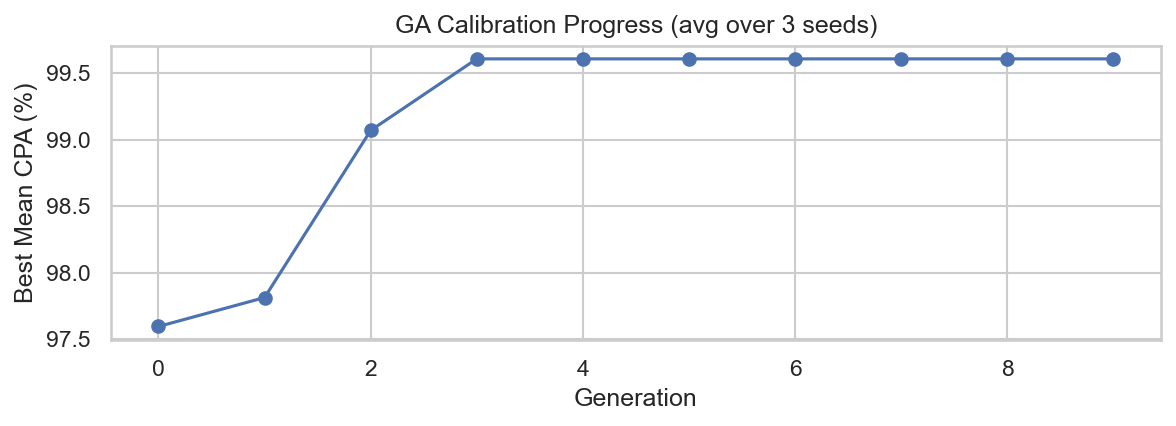

Held-out CPA (seed=123): 96.2% (default: 91.2%)


In [ ]:
# GA optimization of CA parameters (p_slow, p_stop) to maximize CPA
# Su dung nhieu seed khac nhau de tranh overfit vao 1 gia tri Moran's I nhat dinh
GA_SEEDS = [1, 42, 99]

def run_ca_density(ps, pt, seed, L=100, LN=2, DENS=0.3, V_MAX=5, TS=500):
    np.random.seed(seed)
    r = (np.random.random((LN, L)) < DENS).astype(int)
    v = np.random.randint(1, V_MAX+1, (LN, L)).astype(int) * r
    density = np.zeros(L)
    for _ in range(TS):
        for ln in range(LN):
            r[ln], v[ln] = ns_step(r[ln], v[ln], ps, pt)
        r, v = lc(r, v)
        density += r[0]
    return density / TS

def fitness(ps, pt):
    cpas = []
    for s in GA_SEEDS:
        ca_dens = run_ca_density(ps, pt, seed=s)
        mi_ca = moran_i_1d(ca_dens)
        cpas.append(max(0, (1 - abs(mi_real - mi_ca)) * 100))
    return np.mean(cpas)

POP_SIZE, N_GEN = 20, 10
np.random.seed(0)
pop = np.random.uniform(0, 0.5, (POP_SIZE, 2))
best_fit, best_params = 0, None
fit_history = []

for gen in range(N_GEN):
    fits = np.array([fitness(ps, pt) for ps, pt in pop])
    for i in range(POP_SIZE):
        if fits[i] > best_fit:
            best_fit, best_params = fits[i], pop[i].copy()
    fit_history.append(best_fit)
    new_pop = []
    for _ in range(POP_SIZE):
        idxs = np.random.choice(POP_SIZE, 3, replace=False)
        p1 = pop[idxs[np.argmax(fits[idxs])]]  # select best (maximize CPA)
        idxs = np.random.choice(POP_SIZE, 3, replace=False)
        p2 = pop[idxs[np.argmax(fits[idxs])]]  # select best (maximize CPA)
        alpha = np.random.random()
        child = alpha * p1 + (1 - alpha) * p2
        child += np.random.normal(0, 0.05, 2)
        child = np.clip(child, 0.01, 0.5)
        new_pop.append(child)
    pop = np.array(new_pop)

P_SLOW_GA, P_STOP_GA = best_params
print(f'GA optimized: P_SLOW={P_SLOW_GA:.4f}, P_STOP={P_STOP_GA:.4f}')
print(f'  Mean CPA over seeds {GA_SEEDS}: {best_fit:.1f}%')

plt.figure(figsize=(8, 3))
plt.plot(fit_history, marker='o')
plt.xlabel('Generation'); plt.ylabel('Best Mean CPA (%)')
plt.title('GA Calibration Progress (avg over 3 seeds)')
plt.tight_layout()
plt.savefig(OM + '/ga_calibration.png', dpi=150)
plt.show()

# Danh gia tren seed hoan toan moi (held-out)
opt_dens = run_ca_density(P_SLOW_GA, P_STOP_GA, seed=123)
mi_ca_opt = moran_i_1d(opt_dens)
cpa_opt = max(0, (1 - abs(mi_real - mi_ca_opt)) * 100)
print(f'Held-out CPA (seed=123): {cpa_opt:.1f}% (default: {cpa:.1f}%)')

## 13. Kepler.gl Export
Export grid-level CSV for visualization in Kepler.gl.

In [ ]:
try:
    kep = t[['Latitude', 'Longitude', 'Date', 'Hour', 'Year', 'Month',
             'Injury_Collisions', 'Fatalities', 'Police_Division', 'Neighbourhood']].copy()
    kep = kep.dropna(subset=['Latitude', 'Longitude', 'Date', 'Hour'])
    kep['lat'] = pd.to_numeric(kep['Latitude'], errors='coerce').round(4)
    kep['lon'] = pd.to_numeric(kep['Longitude'], errors='coerce').round(4)
    kep = kep.dropna(subset=['lat', 'lon'])
    kep['Hour'] = pd.to_numeric(kep['Hour'], errors='coerce').fillna(12).astype(int).clip(0, 23)
    kep['timestamp'] = pd.to_datetime(kep['Date'], errors='coerce') + pd.to_timedelta(kep['Hour'], unit='h')
    kep['timestamp'] = kep['timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')
    kep = kep.dropna(subset=['timestamp'])
    risk_model = t.groupby(['Hour', 'Neighbourhood', 'Month']).agg(
        risk_est=('Injury_Collisions', lambda x: (x == 'YES').mean())
    ).reset_index()
    risk_model['risk_est'] = risk_model['risk_est'].fillna(0).clip(0, 1).round(4)
    kep = kep.merge(risk_model, on=['Latitude', 'Longitude', 'Hour', 'DayOfWeek'], how='left')
    kep['risk_score'] = kep['risk_est'].fillna(kep['risk_est'].median()).round(4)
    # Per paper: 4 time groups (0-5, 6-11, 12-17, 18-23)
    def cong(h):
        if h in [0,1,2,3,4,5]: return 0
        if h in [6,7,8,9,10,11]: return 1
        if h in [12,13,14,15,16,17]: return 2
        return 3
    kep['congestion_level'] = kep['Hour'].map(cong).astype(int)
    kep['g_i'] = ((kep['lat'] - LAT_ORIGIN) / CELL_LAT).fillna(0).astype(int)
    kep['g_j'] = ((kep['lon'] - LON_ORIGIN) / CELL_LON).fillna(0).astype(int)
    cell_density = kep.groupby(['g_i', 'g_j']).size().reset_index(name='cell_count')
    kep = kep.merge(cell_density, on=['g_i', 'g_j'], how='left')
    kep['collision_density'] = kep['cell_count'].fillna(0).astype(int).clip(0, 999)
    kep['year'] = pd.to_datetime(kep['Date'], errors='coerce').dt.year.fillna(0).astype(int)
    max_rows = 100  # per paper: small sample
    kep_out = kep[['lat', 'lon', 'timestamp', 'year', 'Hour', 'risk_score',
                   'congestion_level', 'collision_density', 'Police_Division', 'Neighbourhood']].copy()
    kep_out.columns = ['lat', 'lon', 'timestamp', 'year', 'hour', 'risk_score',
                       'congestion_level', 'collision_density', 'police_division', 'neighbourhood']
    if len(kep_out) > 200000:
        kep_out = kep_out.sample(n=200000, random_state=42).sort_values('timestamp')
    kep_path = _os.path.join(OM, 'kepler_output.csv')
    kep_out.to_csv(kep_path, index=False)
    print(f'Kepler.gl CSV: {kep_path} ({len(kep_out):,d} rows)')
except Exception as e:
    print(f'Kepler export skipped: {e}')

Kepler.gl CSV: c:\Users\ADMIN\Desktop\TT\B2205935-LeNgocDuc-TranThanhPhuc-tuan-02\outputs\toronto_new\kepler_output.csv (200,000 rows)
